In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from skimage.morphology import disk
from scipy.signal.windows import hann
from quantem.core.visualization.custom_normalizations import NormalizationConfig
from matplotlib.patches import Rectangle
from scipy.signal import fftconvolve
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography
import numpy as np
from scipy.signal import fftconvolve
from scipy.ndimage import maximum_filter, label, find_objects
from scipy.ndimage import shift
from scipy.ndimage import zoom
from skimage.registration import phase_cross_correlation

def crop_white_border(rgba):
    # Convert to grayscale and find non-white rows/cols
    gray = rgba[..., :3].mean(axis=2)
    mask = gray < 255
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rgba[rmin:rmax+1, cmin:cmax+1]
from scipy.ndimage import shift as nd_shift

from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")

from quantem.core.utils.imaging_utils import detect_bragg_disks, bragg_disks_to_masks

from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

import abtem
import ase
import logging
logging.getLogger("hyperspy").setLevel(logging.ERROR)
def cmplx_array_to_rgba(cmplx_valued_array, vmin=0.02, vmax=0.98):
    scaled_amplitude = np.abs(cmplx_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = np.angle(cmplx_valued_array)
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
    return rgba

def real_array_to_rgba(real_valued_array, vmin=0.02, vmax=0.98, cmap='gray'):
    scaled_amplitude = np.abs(real_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = None
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase, cmap=cmap)
    return rgba

from abtem.core.energy import energy2sigma

def subpixel_shift(img, shift):
    """
    Circularly shift a 2D (or 3D with leading singleton) array by a
    sub-pixel amount using the Fourier shift theorem.
    shift: (dy, dx) in pixels, applied along the last two axes.
    Positive dx shifts content to the right (same convention as np.roll).
    """
    dy, dx = shift
    *_, ny, nx = img.shape
    
    F = np.fft.fft2(img, axes=(-2, -1))
    
    ky = np.fft.fftfreq(ny)[:, None]
    kx = np.fft.fftfreq(nx)[None, :]
    
    phase_ramp = np.exp(-2j * np.pi * (ky * dy + kx * dx))
    
    F_shifted = F * phase_ramp
    shifted = np.fft.ifft2(F_shifted, axes=(-2, -1))
    
    # if the input was real, the output should be too (up to numerical noise)
    if np.isrealobj(img):
        shifted = shifted.real
    
    return shifted

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

def compute_global_shift_xcorr(img_ref, img_target, upsample_factor=20):
    """
    Compute the global (row_shift, col_shift) i.e. (dy, dx) that best
    aligns img_target to img_ref, using Fourier-based phase cross-correlation.

    Parameters
    ----------
    img_ref : reference image (e.g. gt_image)
    img_target : image to register against the reference (e.g. phase)
    upsample_factor : controls sub-pixel precision (20 -> 1/20 px precision)

    Returns
    -------
    shift : (dy, dx) — apply as target_shifted = shift(img_target, shift) to align it to img_ref
    error : normalized RMS registration error
    diffphase : global phase difference (usually irrelevant here)
    """
    shift, error, diffphase = phase_cross_correlation(
        img_ref, img_target, upsample_factor=upsample_factor, normalization='phase'
    )
    return shift, error, diffphase

quantEM version: 0.1.8


In [3]:
def generate_two_rectangles_spaced(d, vis=True, size=(10, 10, 4)):
    lc = 4
    layer_thickness = lc / 2  # fcc100 interlayer spacing along z is a/2

    atoms = ase.build.fcc100(
        "Au",
        a=lc,
        size=size,          # (nx, ny, n_layers)
        orthogonal=True,
        periodic=True,
    )

    atoms2 = atoms.copy()  # identical, unrotated copy
    atoms2.rotate(90, "z", center='COM') # rotate around com
    max_x_val = atoms.positions[:, 0].max()
    min_y_val = atoms.positions[:, 1].min()
    min_x_val2 = atoms2.positions[:, 0].min()
    min_y_val2 = atoms2.positions[:, 1].min()

    # align both to y=0 at bottom, gap centered at x=0
    atoms.translate([-max_x_val - d/2, -min_y_val, 0])
    atoms2.translate([-min_x_val2 + d/2, -min_y_val2, 0])

    atoms = atoms + atoms2

    # now center the whole thing in a 100x100 cell
    atoms.cell = [100, 100, layer_thickness * size[2]]
    atoms.center()

    if vis:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
        abtem.show_atoms(
            atoms, ax=ax1,
            title="Two fcc100 slabs, beam view",
            merge=0.1, scale=1,
        )
        abtem.show_atoms(
            atoms, ax=ax2, plane="xz", scale=1,
            title="Side view (xz)", merge=0.1,
        )
        abtem.show_atoms(
            atoms, ax=ax3, plane="yz", scale=1,
            title="Side view (yz)", merge=0.1,
        )
        fig.tight_layout()

    return atoms

In [4]:
def generate_square_atoms():
    lc = 4
    layer_thickness = lc * np.sqrt(3)/3
    z_layers = 6
    atoms = ase.build.fcc111(
        "Au",
        a = lc,
        size=(1,2,z_layers),
        orthogonal=True,
        periodic=False,
    )
    # atoms *= (26,15,1)
    # atoms *= (26,15,1)
    atoms *= (38,22,1)

    threshold = 12 * (np.sqrt(2))-0.01  # ≈ 2.121
    threshold2 = 8 * (np.sqrt(2)*np.sqrt(3))-0.01  # ≈ 2.121


    positions = atoms.get_positions()
    mask = positions[:, 0] < threshold
    del atoms[mask]
    positions = atoms.get_positions()  # recompute!

    mask = positions[:, 1] < threshold2
    del atoms[mask]

    threshold = 75 * (np.sqrt(2)) - 12*np.sqrt(2) +0.01  # ≈ 2.121
    threshold2 = 43 * (np.sqrt(2)*np.sqrt(3)) - 9 * (np.sqrt(2)*np.sqrt(3)) -0.01  # ≈ 2.121


    positions = atoms.get_positions()
    mask = positions[:, 0] > threshold
    del atoms[mask]
    positions = atoms.get_positions()  # recompute!

    mask = positions[:, 1] > threshold2
    del atoms[mask]

    atoms.center(vacuum=0.00001, axis=2)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
    abtem.show_atoms(
        atoms ,
        ax=ax1,
        title="Supported nanoparticle beam view",
        merge=0.1,
        scale=1,
    )
    abtem.show_atoms(
        atoms ,
        ax=ax2,
        plane="xz",
        scale=1,
        title="Supported nanoparticle side view",
        merge=0.1,
    )
    abtem.show_atoms(
        atoms ,
        ax=ax3,
        plane="yz",
        scale=1,
        title="Supported nanoparticle side view",
        merge=0.1,
    )
    fig.tight_layout();
    return atoms

In [5]:
def generate_two_rectangles_spaced(d, vis=True, size=(10, 10, 4), angle2=45):
    lc = 4
    layer_thickness = lc / 2  # fcc100 interlayer spacing along z is a/2

    atoms = ase.build.fcc100(
        "Au",
        a=lc,
        size=size,          # (nx, ny, n_layers)
        orthogonal=True,
        periodic=True,
    )

    if angle2 % 90 == 0:
        # simple case: rotating by a multiple of 90 keeps a flat edge facing the gap
        atoms2 = atoms.copy()
        atoms2.rotate(angle2, "z", center='COM')
    else:
        # build an oversized slab so that after rotating by an arbitrary angle,
        # there's still enough material to crop a full rectangle out of the middle
        target_x = size[0] * lc / np.sqrt(2)   # physical target extent (a)
        target_y = size[1] * lc / np.sqrt(2)
        pad_factor = 1.8  # oversize to survive rotation + cropping
        big_size = (
            int(np.ceil(size[0] * pad_factor)),
            int(np.ceil(size[1] * pad_factor)),
            size[2],
        )

        atoms2 = ase.build.fcc100(
            "Au", a=lc, size=big_size, orthogonal=True, periodic=False,
        )
        atoms2.rotate(angle2, "z", center='COM')

        # crop to a centered rectangle of the *target* physical dimensions,
        # so atoms2 has flat top/bottom/left/right edges again despite the
        # crystallographic lattice itself being rotated by angle2
        com = atoms2.get_center_of_mass()
        half_x, half_y = target_x / 2, target_y / 2
        pos = atoms2.positions
        mask = (
            (np.abs(pos[:, 0] - com[0]) <= half_x) &
            (np.abs(pos[:, 1] - com[1]) <= half_y)
        )
        del atoms2[~mask]

    max_x_val = atoms.positions[:, 0].max()
    min_y_val = atoms.positions[:, 1].min()
    min_x_val2 = atoms2.positions[:, 0].min()
    min_y_val2 = atoms2.positions[:, 1].min()

    # align both to y=0 at bottom, gap centered at x=0
    atoms.translate([-max_x_val - d/2, -min_y_val, 0])
    atoms2.translate([-min_x_val2 + d/2, -min_y_val2, 0])

    atoms = atoms #+ atoms2

    # now center the whole thing in a 100x100 cell
    atoms.cell = [100, 100, layer_thickness * size[2]]
    atoms.center()

    if vis:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
        abtem.show_atoms(
            atoms, ax=ax1,
            title="Two fcc100 slabs, beam view",
            merge=0.1, scale=1,
        )
        abtem.show_atoms(
            atoms, ax=ax2, plane="xz", scale=1,
            title="Side view (xz)", merge=0.1,
        )
        abtem.show_atoms(
            atoms, ax=ax3, plane="yz", scale=1,
            title="Side view (yz)", merge=0.1,
        )
        fig.tight_layout()

    return atoms

In [6]:
def generate_potential(atoms, semiangle_cutoff, gpts=64):
    pot_gpts = 512
    # pot_gpts = 16384
    lc = 4
    layer_thickness = lc * np.sqrt(3)/3
    potential = abtem.Potential(
        atoms,
        gpts=(pot_gpts, pot_gpts),
        slice_thickness= layer_thickness,
        device='cpu',
        projection='infinite'
    ).build(
        lazy=False
    )

    energy = 30e3
    # semiangle_cutoff = [8,12,16]
    # semiangle_cutoff = 12

    aberrations = {
        "C10":100,
        "C12":200,
        "C21":30000,
        "C30": 10000
    }
    aberrations = {
        "C10":0,#100,
        "C12":0,#200,
        "C21":0,#30000,
        "C30": 0#10000
    }

    probe = abtem.Probe(
        energy=energy,
        semiangle_cutoff=semiangle_cutoff,
        aberrations=aberrations,
        device='cpu',
    ).match_grid(
        potential
    )
    start = [0,0]
    end = [potential.extent[0],potential.extent[1]]
    gpts = gpts

    grid_scan = abtem.GridScan(
        start=start,
        end=end,
        gpts=(gpts, gpts),
        endpoint=False
    )

    detector = abtem.PixelatedDetector(
        max_angle=None
    )

    fig,ax = plt.subplots()
    abtem.show_atoms(atoms,ax=ax)
    grid_scan.add_to_plot(ax)
    measurement = probe.scan(
        potential,
        grid_scan,
        detector,
    ).compute()


    measurement_cropped = measurement.crop(gpts=(256,256))

    dose = 1e15

    intensity_measurement_noisy = measurement_cropped.poisson_noise(dose)
    dataset_noisy = intensity_measurement_noisy.to_quantem()
    dset_6 = dataset_noisy

    PROBE_ENERGY = energy # eV
    PROBE_SEMIANGLE_6 = semiangle_cutoff # mrad
    PROBE_DEFOCUS = 0 # A 
    return potential, dset_6

In [7]:
def preprocess_set(dset_6, semiangle_cutoff, force_com_rotation=0, rng=0, num_iters=125, batch_size=128, device="cuda:1"):
    pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
    aberrations = {
        "C10":0,#100,
        "C12":0,#200,
        "C21":0,#30000,
        "C30": 0#10000
    }
    PROBE_ENERGY = 30e3
    probe_params = {
        "energy": PROBE_ENERGY,
        "C10": aberrations["C10"],
        "semiangle_cutoff": semiangle_cutoff,
        "C21": aberrations["C21"],
        "C12": aberrations["C12"],
        "C30": aberrations["C30"]
    }

    pdset_6.preprocess(
        force_com_rotation=force_com_rotation,
        force_com_transpose=0,
        plot_com=False,
        probe_energy=PROBE_ENERGY,
        com_fit_function='no_shift'
    )

    obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
        obj_type="complex",
        num_slices=1,
    )

    probe_model_pix = ProbePixelated.from_params(
        probe_params=probe_params,
    )

    detector_model = DetectorPixelated()


    # logger = None
    logger_pix = LoggerPtychography(
        log_dir = "./logs",
        run_prefix=dset_6.name,
        run_suffix="pix",
        log_images_every=10,
        log_probe_images=False,
    )

    ptycho_pix_6 = Ptychography.from_models( 
        dset=pdset_6,
        obj_model=obj_model_pix,
        probe_model=probe_model_pix,
        detector_model=detector_model,
        logger=logger_pix,
        rng=42,
        #wave_ground_truth=dset_wave_ground_truth,
    )

    ptycho_pix_6.preprocess(
        obj_padding_px=(0, 0),
        val_ratio=0.0,
    )
    return ptycho_pix_6

def reconstruct_object(ptycho_pix_6, semiangle_cutoff, force_com_rotation=0, rng=0, num_iters=125, batch_size=128, device="cuda:1", reset=True):




    scheduler_params = {
        "object": { ## scheduler kwargs are passed to the scheduler (of type type)
            "type": "plateau", ## i like plateau for many cases
            "factor":0.2,

        },
        "probe": {
            "type": "plateau",
            "factor":0.2,

        },
        "dataset": { 
            "type": "plateau",  ## exp is also frequently used 
            "factor":0.2,
        }
    }

    constraints_stage1 = {
        "object": {
        },
    }
    
    opt_params = {
            "object": {
                "type": "adamw", 
                "lr": 0.1e-1, 
            },
            "probe": {
                "type": "adamw", 
                "lr": 1e-3, 
            },
            "dataset": { ### for optimizing over descan shifts and probe positions
                "type": "adamw",
                "lr": 0.0,
            }
    }
    ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
        num_iters=num_iters,
        reset=reset,
        optimizer_params=opt_params,
        scheduler_params=scheduler_params,
        constraints=constraints_stage1, 
        batch_size=batch_size,
        device=device,
        store_snapshots_every=1,
        autograd=False,
        autograd_random=False,
        disk_phase='disk_phase',
        rng=rng
    )
    return ptycho_pix_reconstruct_6

In [20]:
# convergence_angle = 12
# # atoms = generate_two_rectangles_spaced(30, size=(25,25,4))
# atoms = generate_square_atoms()
# potential, noisy_dataset = generate_potential(atoms, convergence_angle, gpts=64)
# ptycho_pix_1 = preprocess_set(noisy_dataset, convergence_angle, force_com_rotation=0)
ptycho_pix_reconstruct_1 = reconstruct_object(ptycho_pix_1, convergence_angle, rng=1,batch_size=64, device="cuda:1", num_iters=125, reset=True)

  0%|          | 0/125 [00:00<?, ?it/s]

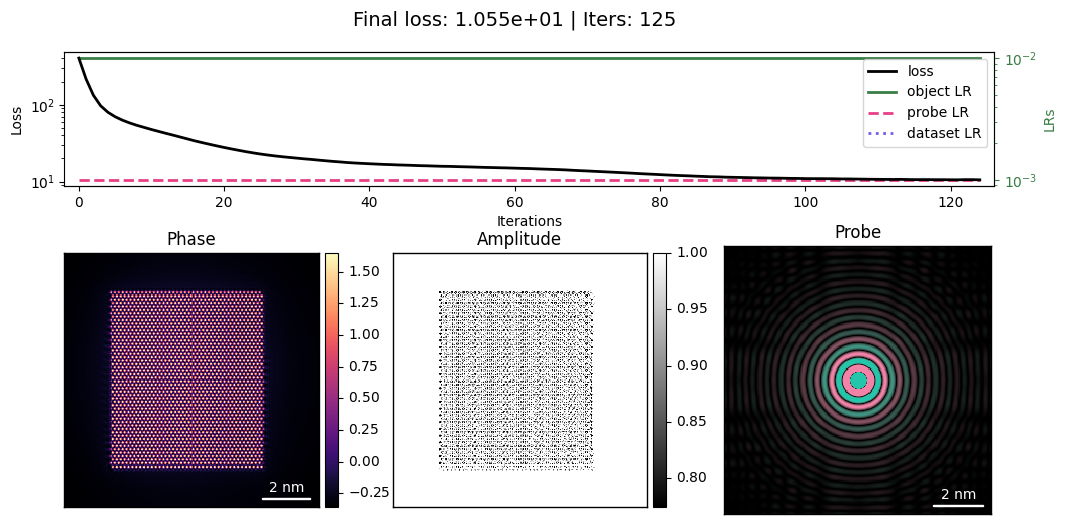

(<Figure size 1200x1200 with 2 Axes>, <Axes: >)

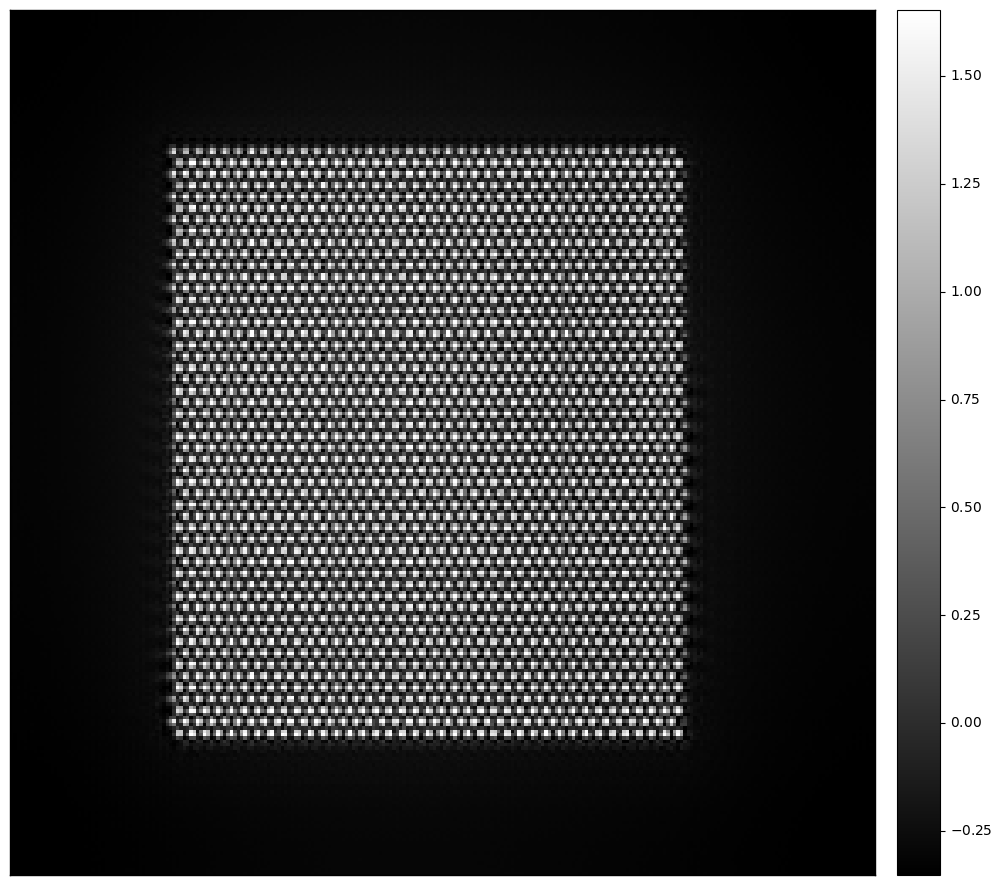

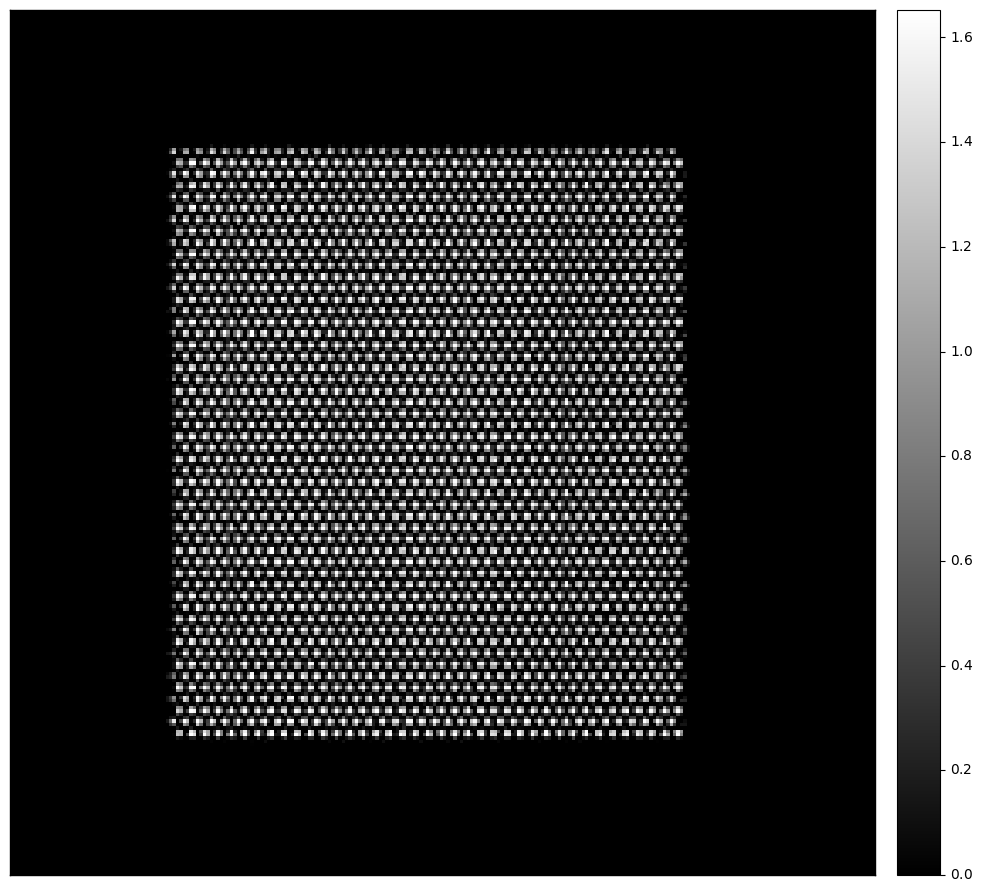

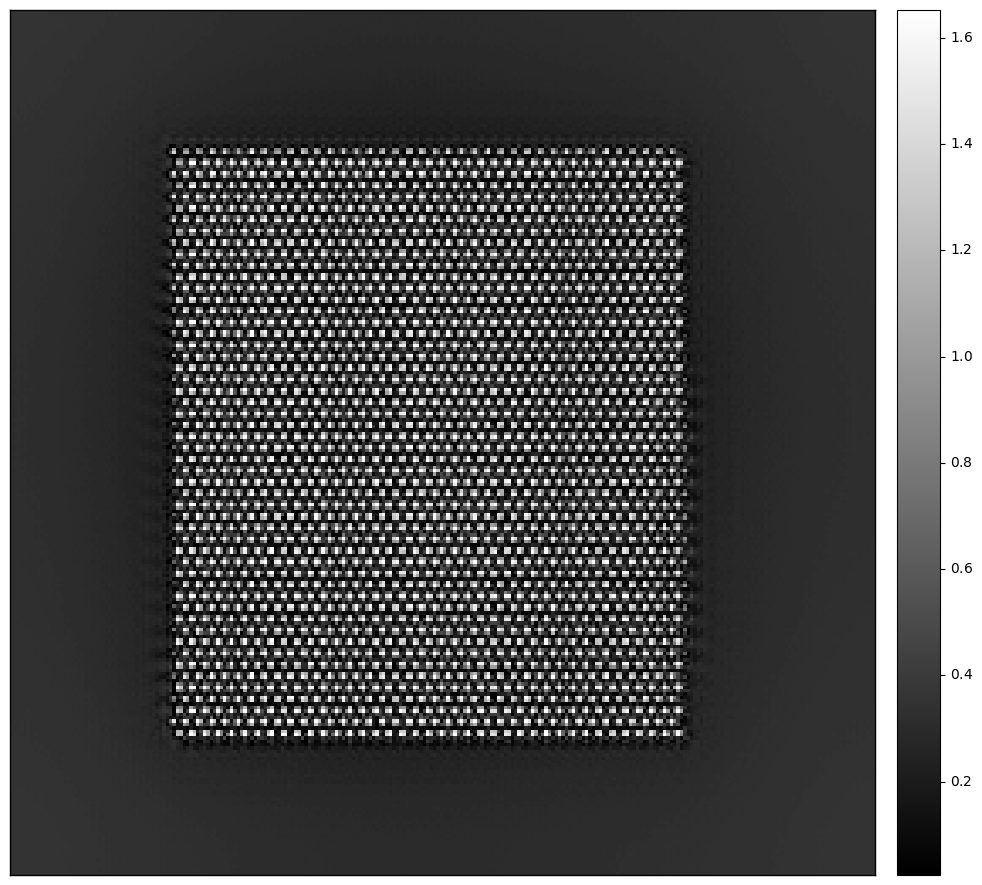

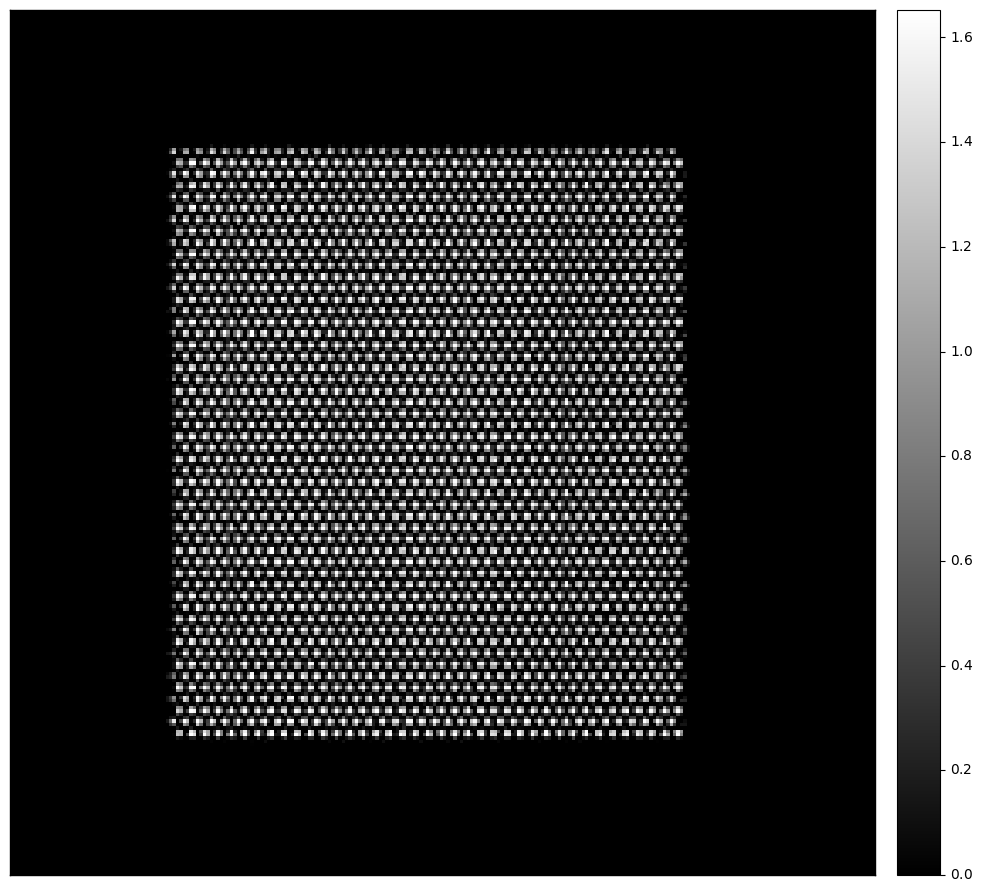

In [22]:
ptycho_pix_reconstruct_1.visualize()
show_2d(np.angle((ptycho_pix_reconstruct_1.obj[0])),cbar=True,axsize=(12,12))
show_2d(np.angle((ptycho_pix_reconstruct_1.obj[0])).clip(0),cbar=True,axsize=(12,12))
show_2d(np.abs(np.angle((ptycho_pix_reconstruct_1.obj[0]))),cbar=True,axsize=(12,12))
show_2d(np.abs(np.angle((ptycho_pix_reconstruct_1.obj[0])).clip(0)),cbar=True,axsize=(12,12))


(256, 256)
(256, 256)


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

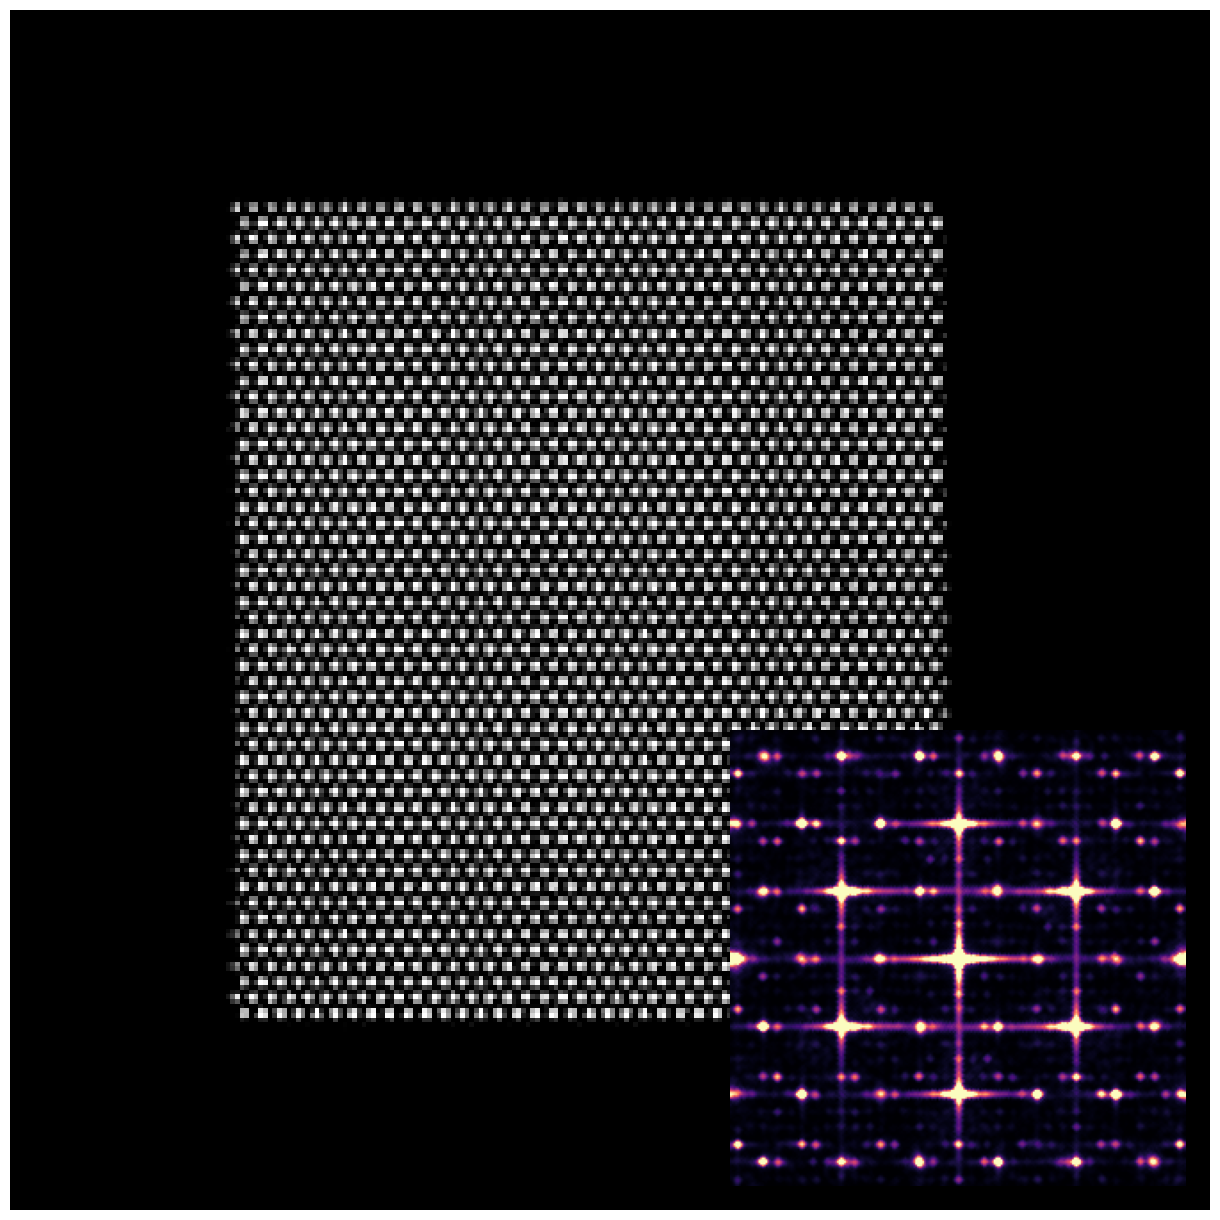

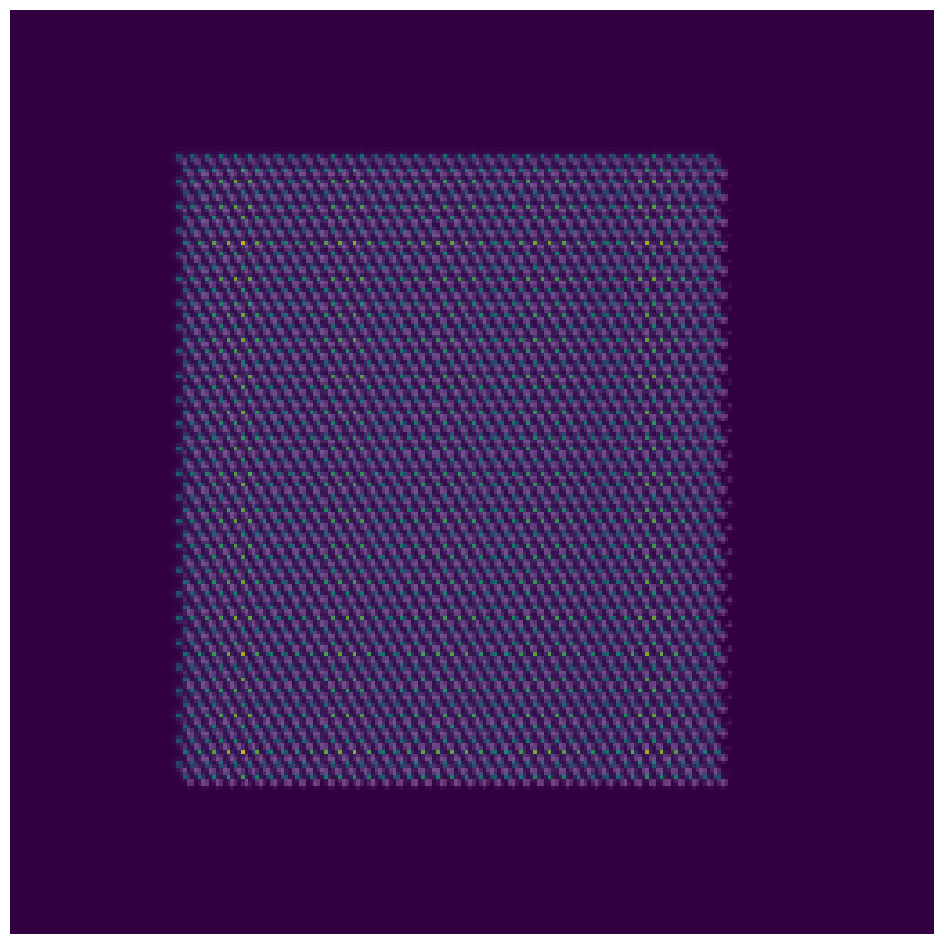

In [23]:
norm_fft = NormalizationConfig(
    interval_type='manual',
    stretch_type='power',
    power=0.5
)

phase = np.angle(ptycho_pix_reconstruct_1.obj[0]).clip(0)
print(phase.shape)
# Build a 2D Hann window
H, W = phase.shape
window = np.outer(hann(H), hann(W))

phase_windowed = phase * window

fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))


fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))
fft_mag[H//2, W//2] = 0

# Convolve with small disk — increase radius for more spreading
kernel = disk(2).astype(float)
kernel /= kernel.sum()
fft_mag = convolve(fft_mag, kernel)


rgba_main = real_array_to_rgba(phase)
rgba_fft = real_array_to_rgba(fft_mag, cmap='magma')

# Compose the final figure
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgba_main,interpolation=None)
ax.axis('off')

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling = ptycho_pix_reconstruct_6.sampling[1],
#     units = 'A',
#     length = 10,
# )

# em.visualization.visualization_utils.add_scalebar_to_ax(
#     ax,
#     ptycho_pix_reconstruct_6.obj[0].shape[1],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+2,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=26
# )

inset_ax = fig.add_axes([0.60, 0.02, 0.38, 0.38])
inset_ax.imshow(rgba_fft)
inset_ax.axis('off')

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling=dset_6.sampling[3],
#     units='$A^{-1}$',
#     length=1
# )
# em.visualization.visualization_utils.add_scalebar_to_ax(
#     inset_ax,
#     dset_6.shape[3],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+1,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=16
# )

from scipy.ndimage import shift
from scipy.ndimage import zoom


potential_all = zoom(potential.array[0::1].sum(0), 0.5, order=3)
potential_sub1 = zoom(potential.array[0::3].sum(0), 0.5, order=3)
potential_sub2 = zoom(potential.array[1::3].sum(0), 0.5, order=3)
potential_sub3 = zoom(potential.array[2::3].sum(0), 0.5, order=3)

print(potential_sub1.shape)
fig, ax = plt.subplots(figsize=(12, 12),)
# ax.imshow(rgba_main,interpolation=None)
# ax.imshow(potential_sub1, alpha=0.25)
# ax.imshow(potential_sub2, alpha=0.25)
# ax.imshow(potential_sub3, alpha=0.25)
ax.imshow(potential_all, alpha=1)
# ax.imshow(potential_sub2, alpha=1)
# ax.imshow(potential_sub3, alpha=1)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)

ax.axis('off')


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

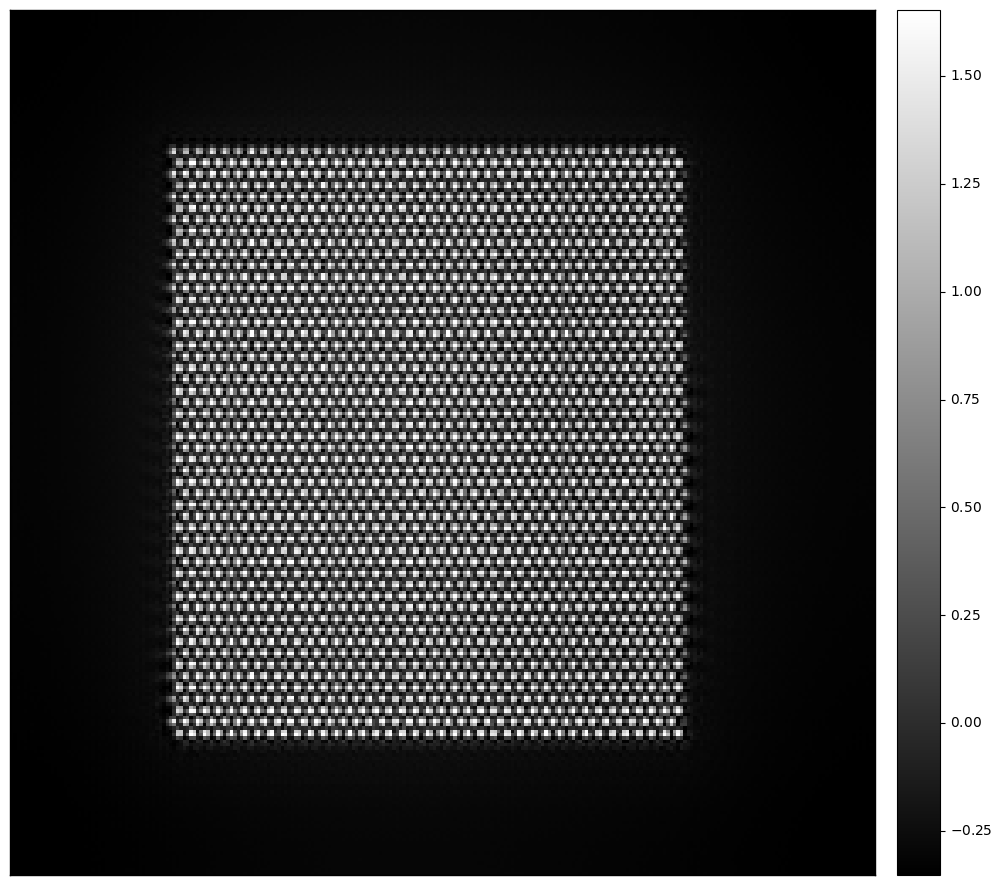

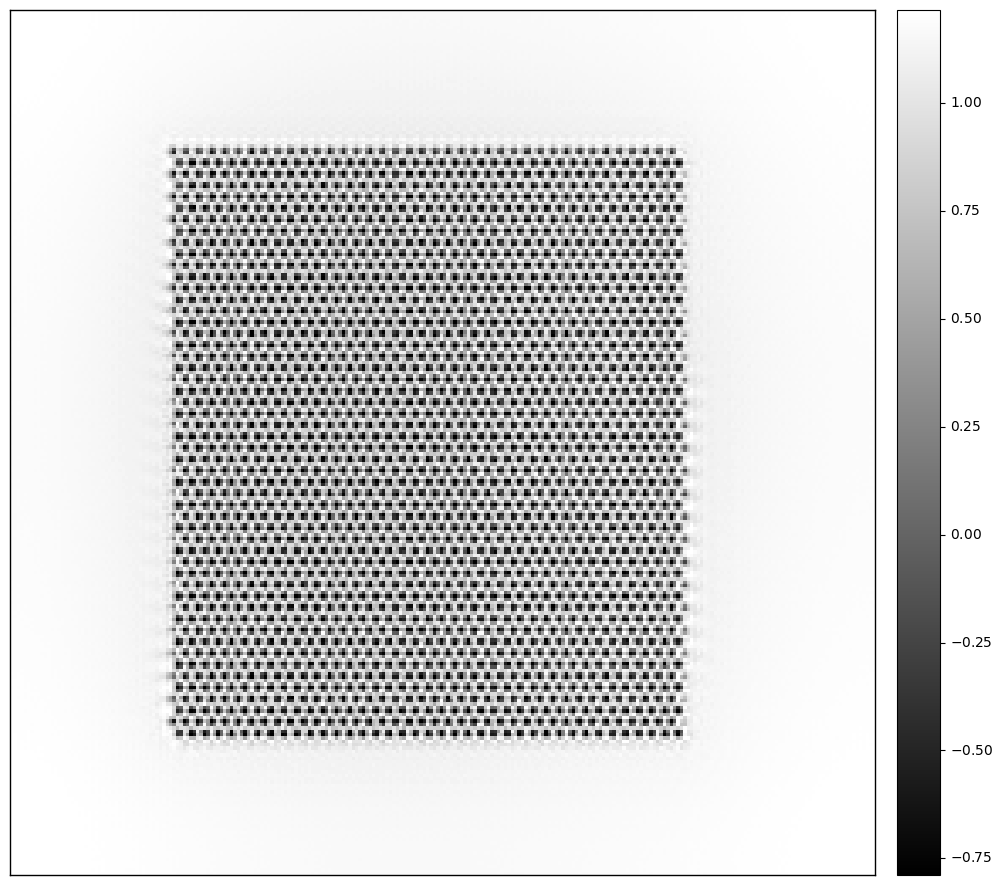

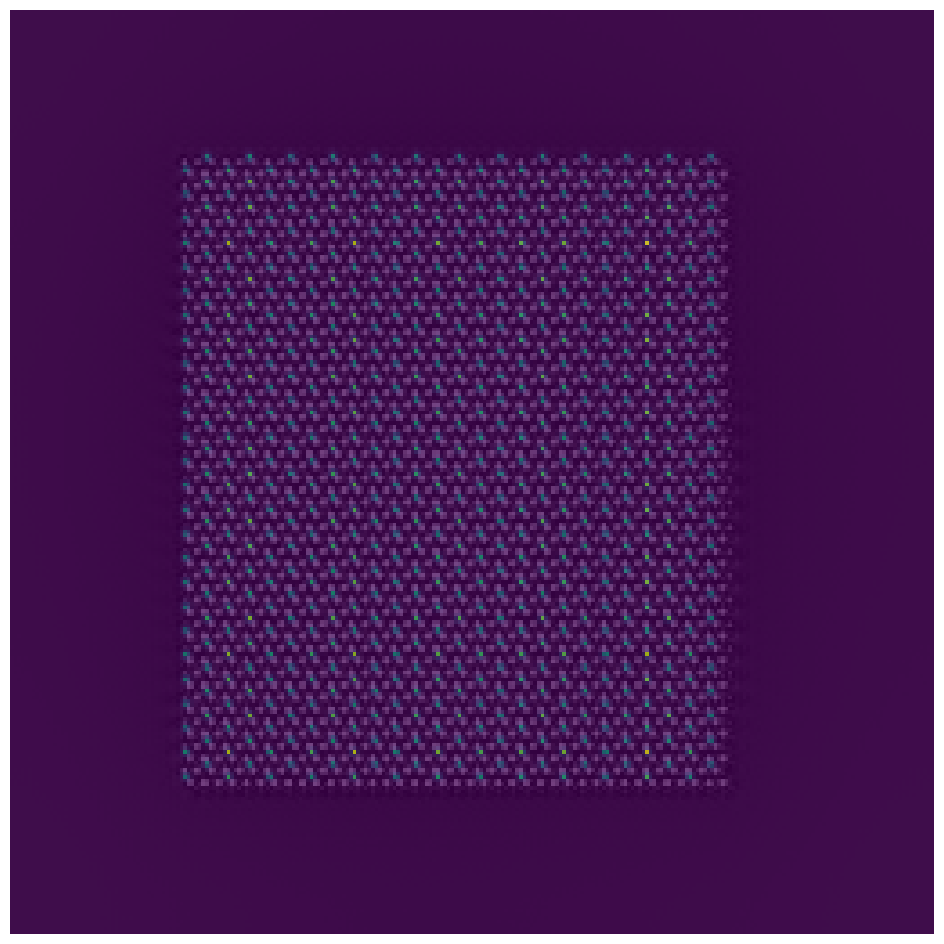

In [24]:
obj_phase = np.abs(np.angle((ptycho_pix_reconstruct_1.obj[0])).clip(0))
obj = ptycho_pix_reconstruct_1.obj[0]

obj_conj = np.conj(obj)

obj_conj_phase = np.angle((obj_conj))

show_2d(np.angle(ptycho_pix_reconstruct_1.obj[0]),cbar=True,axsize=(12,12))

show_2d(np.angle(obj_conj * np.exp(1j * (np.percentile(np.angle(obj), 90) ))),cbar=True,axsize=(12,12))

rgba_main = real_array_to_rgba(obj_conj_phase)
fig, ax = plt.subplots(figsize=(12, 12),)
ax.imshow(potential_sub1, alpha=1)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)
ax.axis('off')


In [12]:
initial_guess = np.ones(ptycho_pix_reconstruct_1.obj.shape, dtype=complex)
obj_repl = obj_conj * np.exp(1j * (np.percentile(np.angle(obj), 90) ))
repl = obj_repl[60:196, 60:196]
initial_guess[0, 60:196, 60:196] = repl

obj_model_pix = ObjectPixelated.from_array(
    initial_obj=initial_guess,
    obj_type="complex",
)
aberrations = {
    "C10":0,#100,
    "C12":0,#200,
    "C21":0,#30000,
    "C30": 0#10000
}
PROBE_ENERGY = 30e3
probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": 12,
    "C21": aberrations["C21"],
    "C12": aberrations["C12"],
    "C30": aberrations["C30"]
}

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()



# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=noisy_dataset.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)
pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(noisy_dataset)#, wave_ground_truth=dset_wave_ground_truth)

pdset_6.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=30e3,
    com_fit_function='no_shift'
)

ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

potential_sub = zoom(potential.array[0::1].sum(0), 0.5, order=3)

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {

}

ptycho_pix_reconstruct_2 = ptycho_pix_6.reconstruct(
num_iters=60,
reset=True,
optimizer_params=opt_params,
scheduler_params=scheduler_params,
constraints=constraints_stage1, 
batch_size=128,
device="cuda:1",
store_snapshots_every=1,
autograd=False,
rng=1
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/4096 [00:00<?, ?probe position/s]

Missing probe parameter 'defocus' in probe_params


  0%|          | 0/60 [00:00<?, ?it/s]

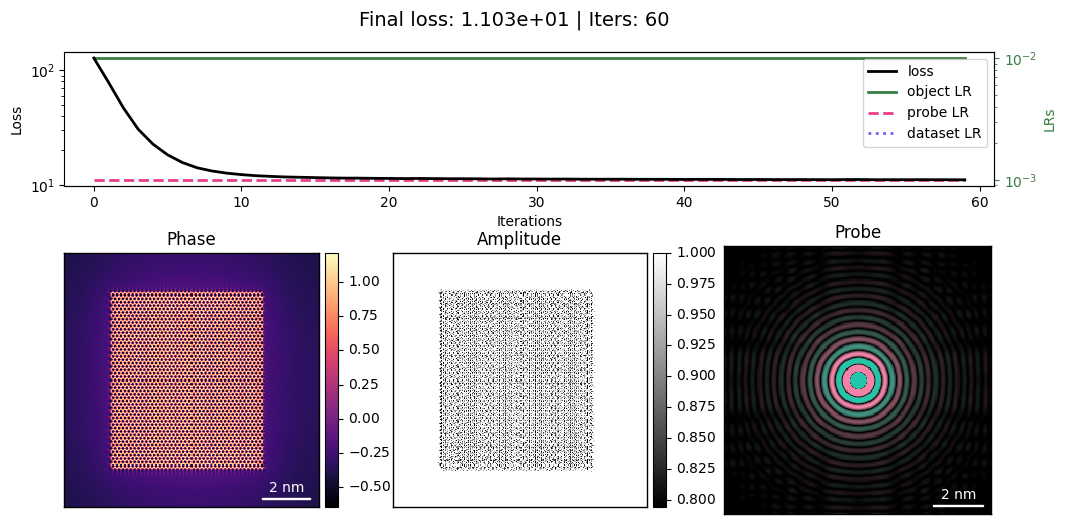

(<Figure size 1200x1200 with 2 Axes>, <Axes: >)

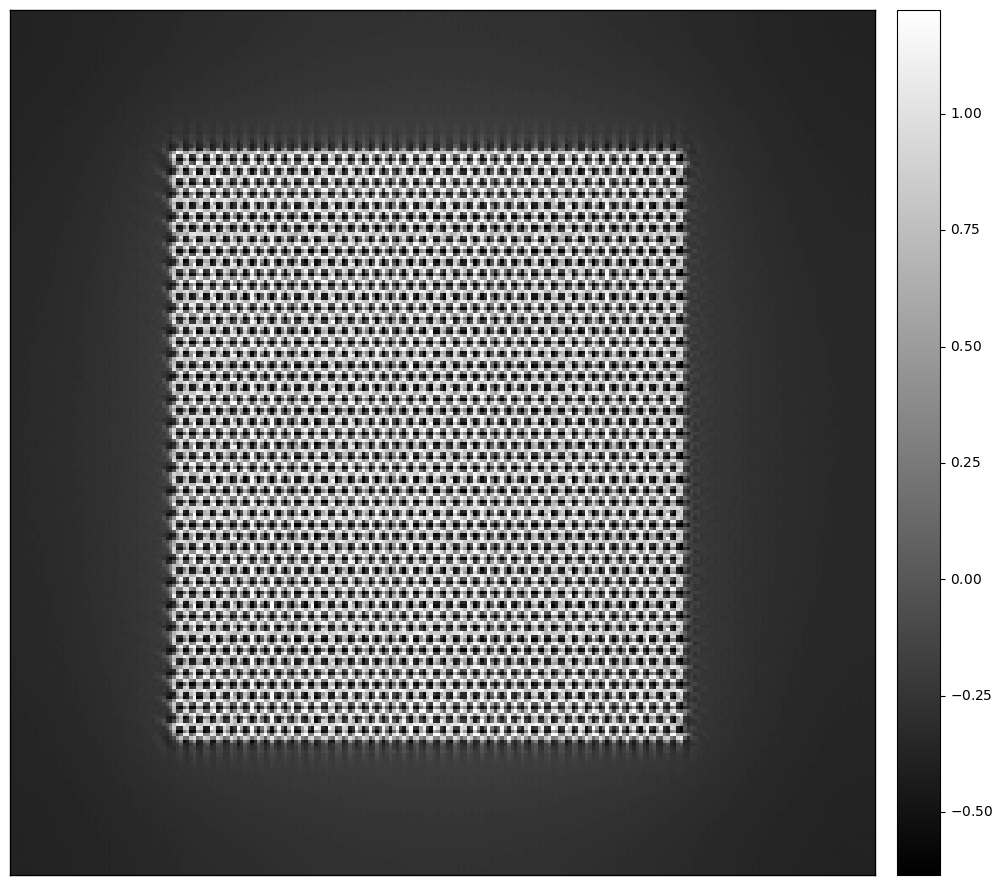

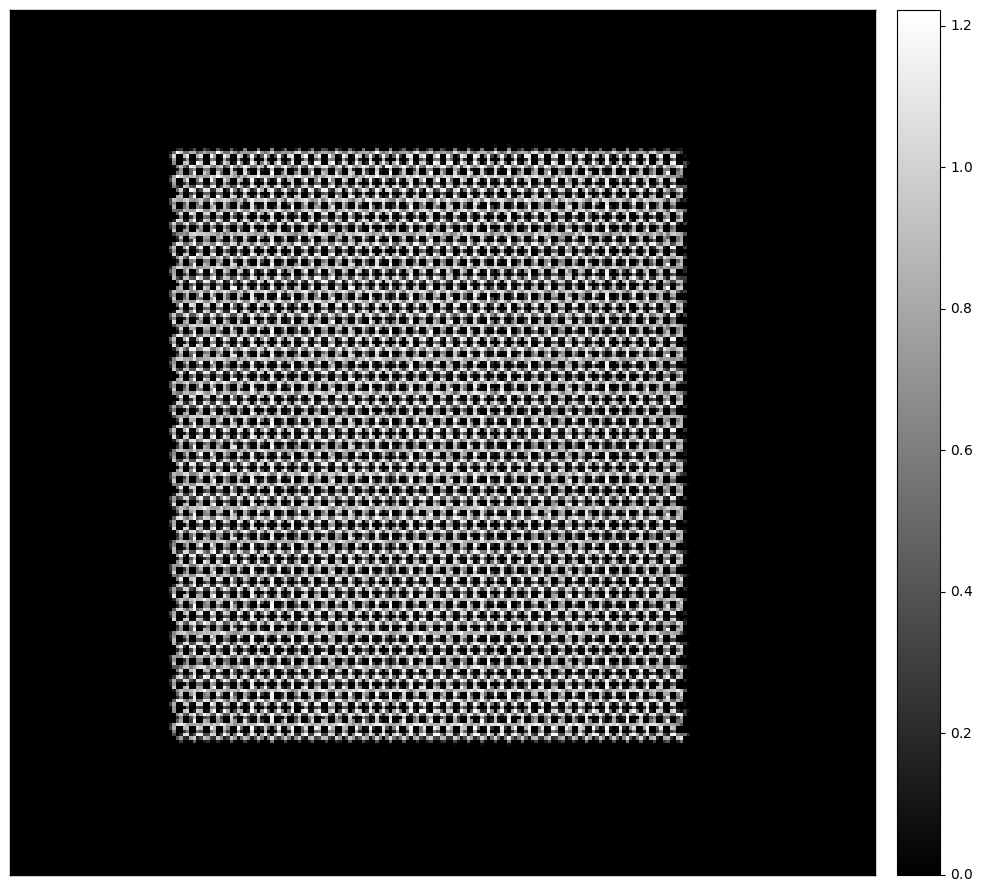

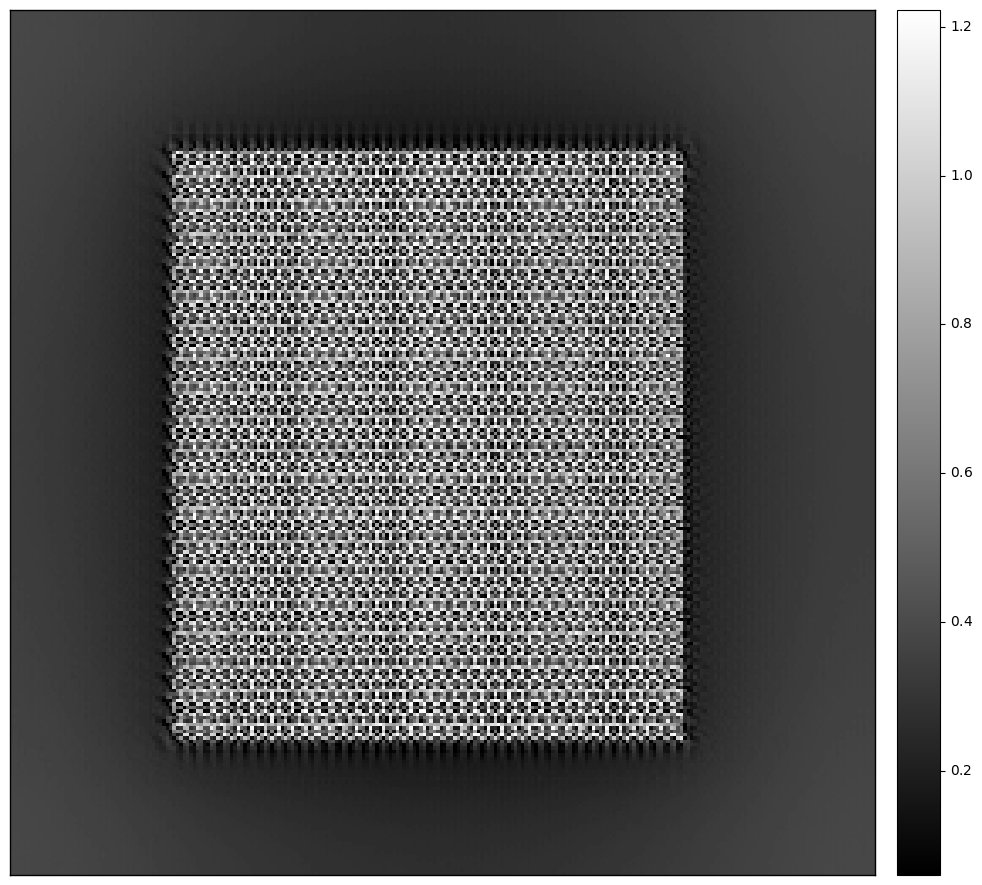

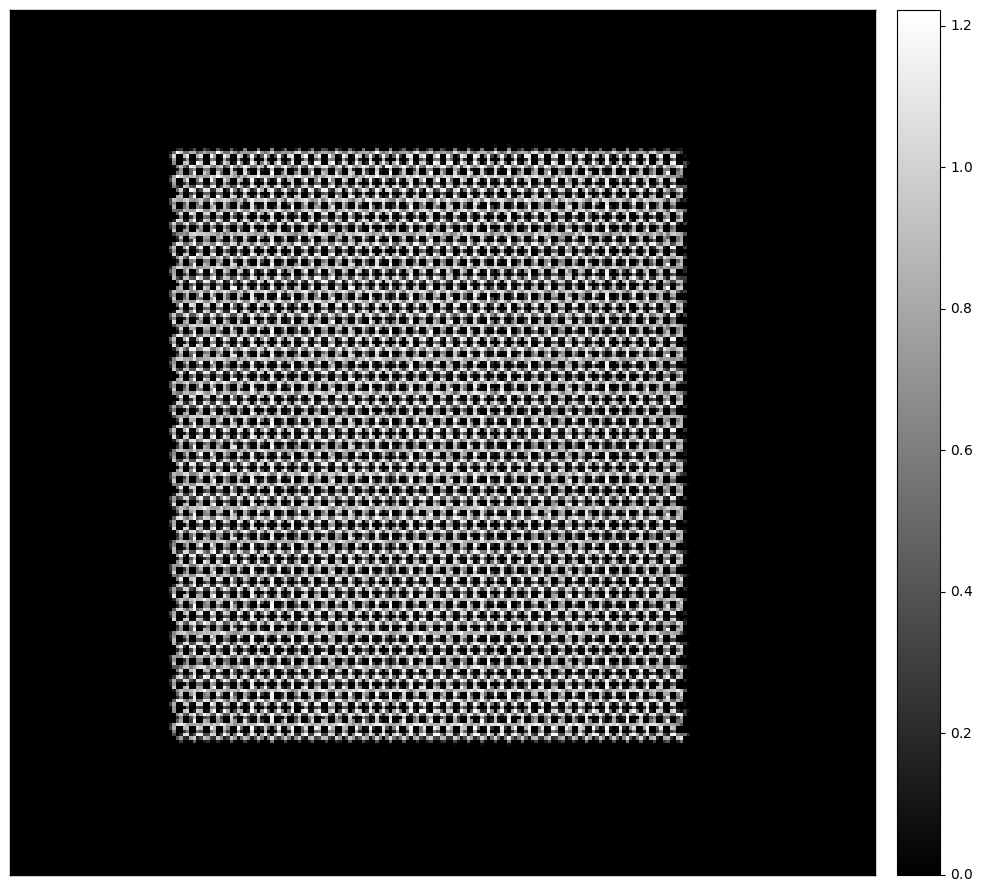

In [13]:
ptycho_pix_reconstruct_2.visualize()
show_2d(np.angle((ptycho_pix_reconstruct_2.obj[0])),cbar=True,axsize=(12,12))
show_2d(np.angle((ptycho_pix_reconstruct_2.obj[0])).clip(0),cbar=True,axsize=(12,12))
show_2d(np.abs(np.angle((ptycho_pix_reconstruct_2.obj[0]))),cbar=True,axsize=(12,12))
show_2d(np.abs(np.angle((ptycho_pix_reconstruct_2.obj[0])).clip(0)),cbar=True,axsize=(12,12))


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

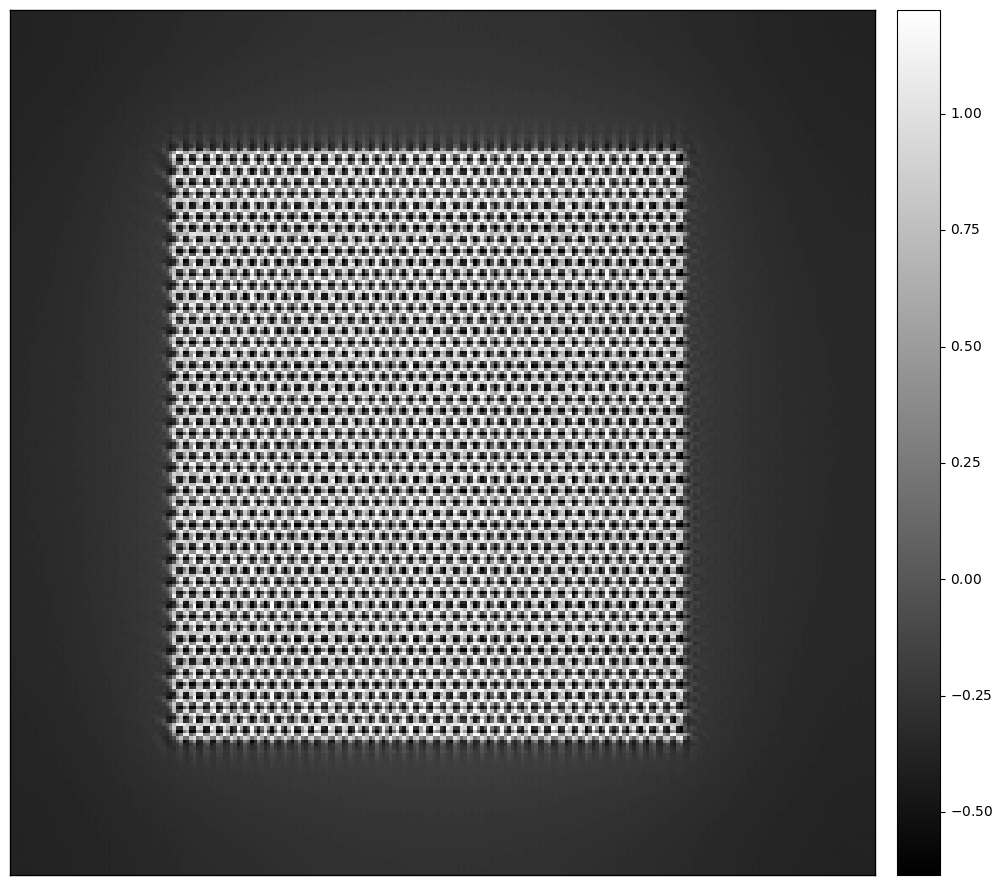

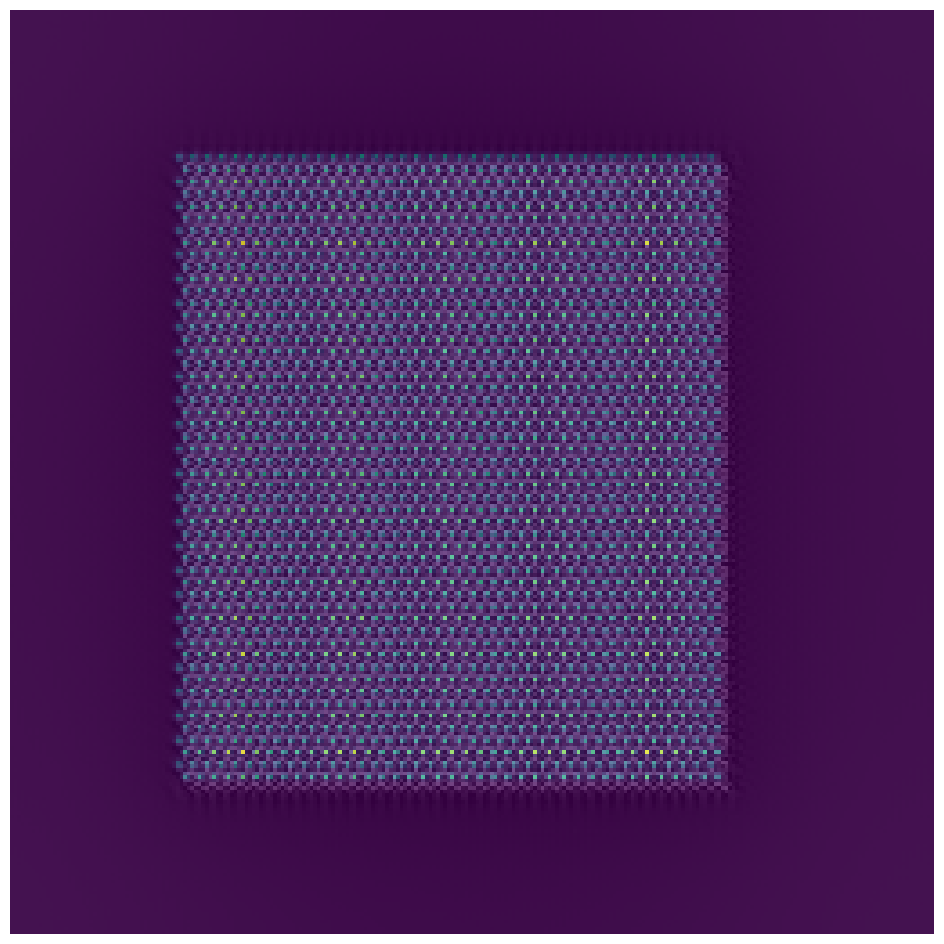

In [14]:
obj_phase = np.abs(np.angle((ptycho_pix_reconstruct_2.obj[0])).clip(0))
obj = ptycho_pix_reconstruct_2.obj[0]
obj_conj = np.conj(obj)
obj_conj_phase = np.angle((obj_conj))

show_2d(np.angle(ptycho_pix_reconstruct_2.obj[0]),cbar=True,axsize=(12,12))

rgba_main = real_array_to_rgba(obj_conj_phase)
fig, ax = plt.subplots(figsize=(12, 12),)
ax.imshow(potential_all, alpha=1)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)
ax.axis('off')


In [25]:
initial_guess = ptycho_pix_reconstruct_1.obj
shift_results = []
for shift_x in np.linspace(-2, 2, 5):
    for shift_y in np.linspace(-2, 2, 5):
        shifted_obj = subpixel_shift(initial_guess, shift=(shift_y, shift_x))
        obj_model_pix = ObjectPixelated.from_array(
            initial_obj=shifted_obj,
            obj_type="complex",
        )
        ptycho_pix_6 = Ptychography.from_models( 
            dset=pdset_6,
            obj_model=obj_model_pix,
            probe_model=probe_model_pix,
            detector_model=detector_model,
            logger=logger_pix,
            rng=42,
        )
        ptycho_pix_6.preprocess(
            obj_padding_px=(0, 0),
            val_ratio=0.0,
        )
        opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 1e-2, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
        }
        ptycho_pix_reconstruct_2 = ptycho_pix_6.reconstruct(
            num_iters=10,
            reset=True,
            optimizer_params=opt_params,
            scheduler_params=scheduler_params,
            constraints=constraints_stage1, 
            batch_size=256,
            device="cuda:1",
            store_snapshots_every=1,
            autograd=False,
            rng=1
        )
        total_loss = ptycho_pix_reconstruct_2._iter_losses[-1]
        # save shift_x, shift_y, and total_loss to a list or file for later analysis
        shift_results.append((shift_x, shift_y, total_loss))
        print(f"Shift (x={shift_x}, y={shift_y}) -> Total Loss: {total_loss}")



Missing probe parameter 'defocus' in probe_params


  0%|          | 0/10 [00:00<?, ?it/s]

Shift (x=-2.0, y=-2.0) -> Total Loss: 11.040446937084198
Missing probe parameter 'defocus' in probe_params


  0%|          | 0/10 [00:00<?, ?it/s]

Shift (x=-2.0, y=-1.0) -> Total Loss: 11.896396696567535
Missing probe parameter 'defocus' in probe_params


...

Shift (x=2.0, y=0.0) -> Total Loss: 10.797130346298218
Missing probe parameter 'defocus' in probe_params


  0%|          | 0/10 [00:00<?, ?it/s]

Shift (x=2.0, y=1.0) -> Total Loss: 10.36945790052414
Missing probe parameter 'defocus' in probe_params


  0%|          | 0/10 [00:00<?, ?it/s]

Shift (x=2.0, y=2.0) -> Total Loss: 11.256734132766724


Sub-pixel minimum: shift_x=1.019, shift_y=0.816, predicted loss=9.6284


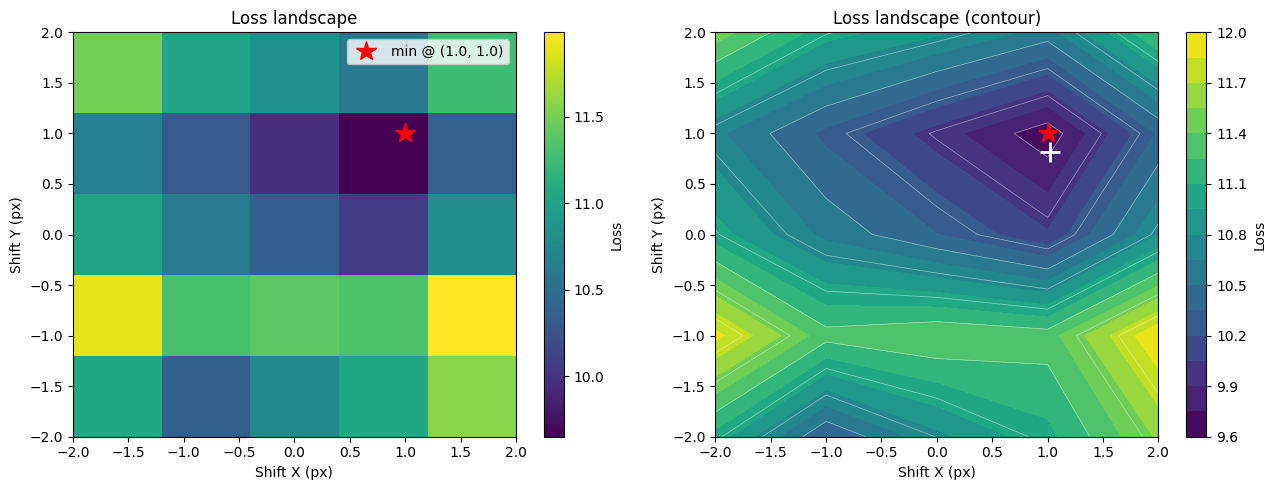

Minimum loss 9.65154 at shift_x=1.0190912699065255, shift_y=0.815558312197451


In [40]:

import numpy as np
import matplotlib.pyplot as plt

# Unpack results
shift_results_arr = np.array(shift_results)  # columns: shift_x, shift_y, loss
shift_x_vals = np.unique(shift_results_arr[:, 0])
shift_y_vals = np.unique(shift_results_arr[:, 1])

# Reshape losses into a 2D grid (rows = shift_y, cols = shift_x, matching your loop order)
loss_grid = shift_results_arr[:, 2].reshape(len(shift_x_vals), len(shift_y_vals)).T
# .T because your loop is: outer=shift_x, inner=shift_y -> array fills row-major as (x, y)
# after reshape(len(x), len(y)) each row corresponds to one shift_x, so transpose to get (y, x) for imshow/contour

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Heatmap ---
im = axes[0].imshow(
    loss_grid,
    extent=[shift_x_vals.min(), shift_x_vals.max(), shift_y_vals.min(), shift_y_vals.max()],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
axes[0].set_xlabel("Shift X (px)")
axes[0].set_ylabel("Shift Y (px)")
axes[0].set_title("Loss landscape")
fig.colorbar(im, ax=axes[0], label="Loss")

# Mark the minimum
min_idx = np.argmin(shift_results_arr[:, 2])
best_x, best_y, best_loss = shift_results_arr[min_idx]
axes[0].plot(best_x, best_y, "r*", markersize=15, label=f"min @ ({best_x:.1f}, {best_y:.1f})")
axes[0].legend()

# --- Contour plot ---
X, Y = np.meshgrid(shift_x_vals, shift_y_vals)
cs = axes[1].contourf(X, Y, loss_grid, levels=20, cmap="viridis")
axes[1].contour(X, Y, loss_grid, levels=10, colors="white", linewidths=0.5, alpha=0.5)
axes[1].plot(best_x, best_y, "r*", markersize=15)
axes[1].set_xlabel("Shift X (px)")
axes[1].set_ylabel("Shift Y (px)")
axes[1].set_title("Loss landscape (contour)")
fig.colorbar(cs, ax=axes[1], label="Loss")
best_x, best_y, pred_loss, spline = find_subpixel_minimum_spline(shift_results)
print(f"Sub-pixel minimum: shift_x={best_x:.3f}, shift_y={best_y:.3f}, predicted loss={pred_loss:.4f}")

# overlay on your contour axes
axes[1].plot(best_x, best_y, "w+", markersize=15, markeredgewidth=2, label="spline min")
plt.tight_layout()
plt.savefig("loss_landscape.png", dpi=150)
plt.show()

print(f"Minimum loss {best_loss:.6g} at shift_x={best_x}, shift_y={best_y}")

In [35]:
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import minimize

def find_subpixel_minimum_spline(shift_results):
    arr = np.array(shift_results)
    x_vals = np.unique(arr[:, 0])
    y_vals = np.unique(arr[:, 1])
    loss_grid = arr[:, 2].reshape(len(x_vals), len(y_vals))  # [x_idx, y_idx]

    spline = RectBivariateSpline(x_vals, y_vals, loss_grid, kx=3, ky=3)

    # start from the grid minimum
    min_idx = np.argmin(arr[:, 2])
    x0 = arr[min_idx, :2]

    result = minimize(
        lambda p: spline(p[0], p[1])[0, 0],
        x0=x0,
        bounds=[(x_vals.min(), x_vals.max()), (y_vals.min(), y_vals.max())],
        method="L-BFGS-B",
    )
    best_x, best_y = result.x
    return best_x, best_y, result.fun, spline
best_x, best_y, pred_loss, spline = find_subpixel_minimum_spline(shift_results)
print(f"Sub-pixel minimum: shift_x={best_x:.3f}, shift_y={best_y:.3f}, predicted loss={pred_loss:.4f}")

# overlay on your contour axes
axes[1].plot(best_x, best_y, "w+", markersize=15, markeredgewidth=2, label="spline min")

Sub-pixel minimum: shift_x=1.019, shift_y=0.816, predicted loss=9.6284


Missing probe parameter 'defocus' in probe_params


  0%|          | 0/30 [00:00<?, ?it/s]

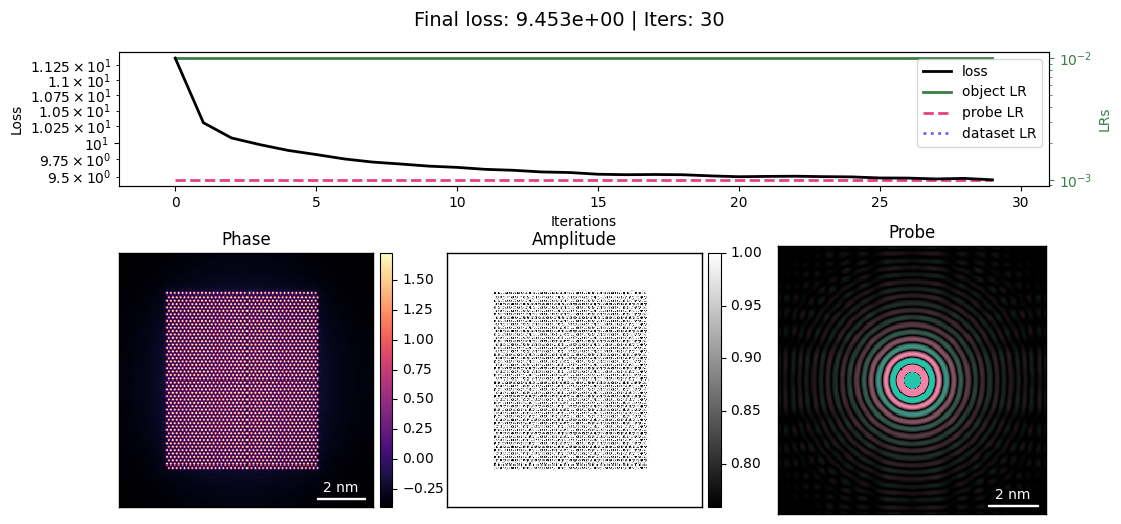

In [115]:
shifted_obj = subpixel_shift(initial_guess, shift=(1,1))
obj_model_pix = ObjectPixelated.from_array(
    initial_obj=shifted_obj,
    obj_type="complex",
)
ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
)
ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)
opt_params = {
"object": {
    "type": "adamw", 
    "lr": 1e-2, 
},
"probe": {
    "type": "adamw", 
    "lr": 1e-3, 
},
"dataset": { ### for optimizing over descan shifts and probe positions
    "type": "adamw",
    "lr": 0.0,
}
}
ptycho_pix_reconstruct_2 = ptycho_pix_6.reconstruct(
    num_iters=30,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=256,
    device="cuda:1",
    store_snapshots_every=1,
    autograd=False,
    rng=1
)
ptycho_pix_reconstruct_2.visualize()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

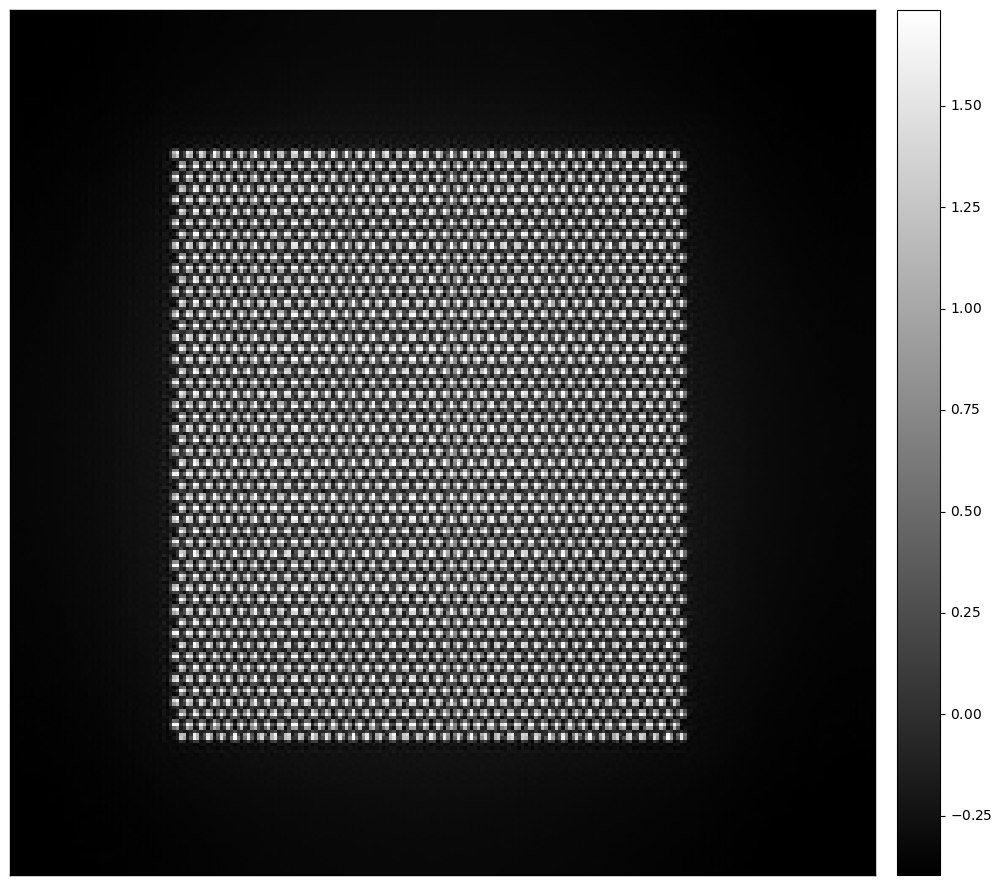

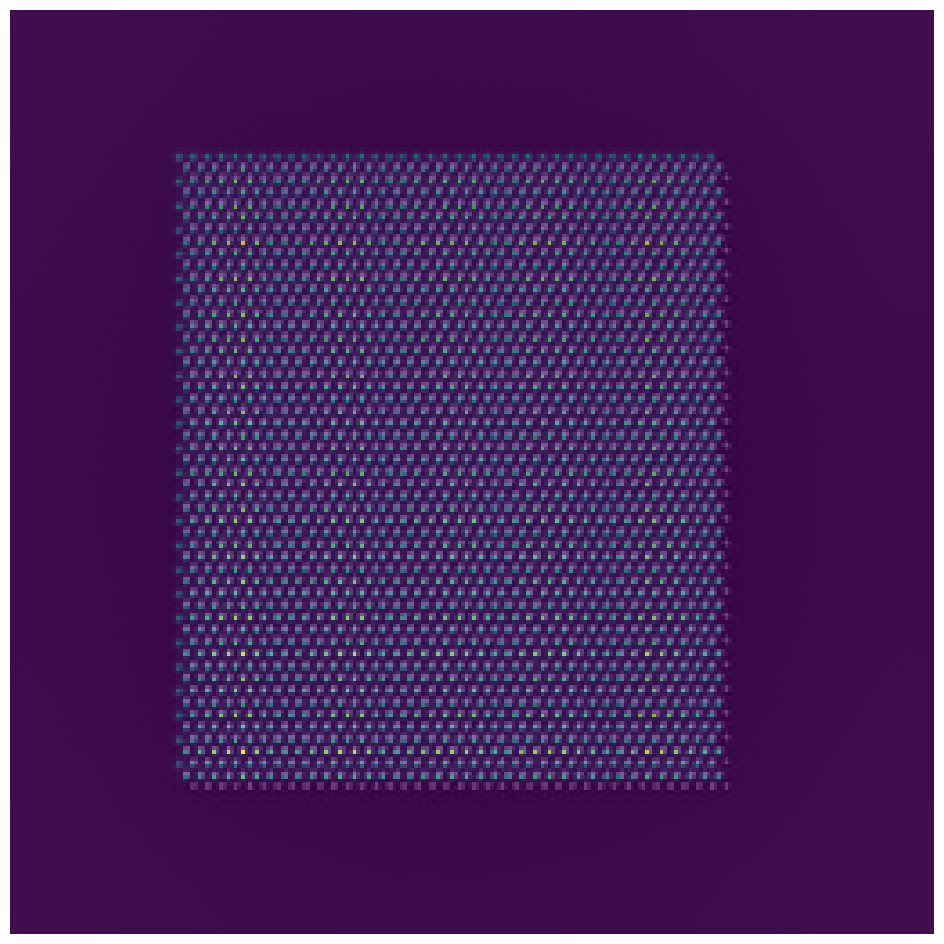

In [116]:
obj_phase = np.abs(np.angle((ptycho_pix_reconstruct_2.obj[0])).clip(0))
obj_phase = np.abs(np.angle(initial_guess[0]).clip(0))

obj = ptycho_pix_reconstruct_2.obj[0]
obj_conj = np.conj(obj)
obj_conj_phase = np.angle((obj_conj))

show_2d(np.angle(ptycho_pix_reconstruct_2.obj[0]),cbar=True,axsize=(12,12))

rgba_main = real_array_to_rgba(np.angle(obj))
fig, ax = plt.subplots(figsize=(12, 12),)
ax.imshow(potential_all, alpha=1)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)
ax.axis('off')


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

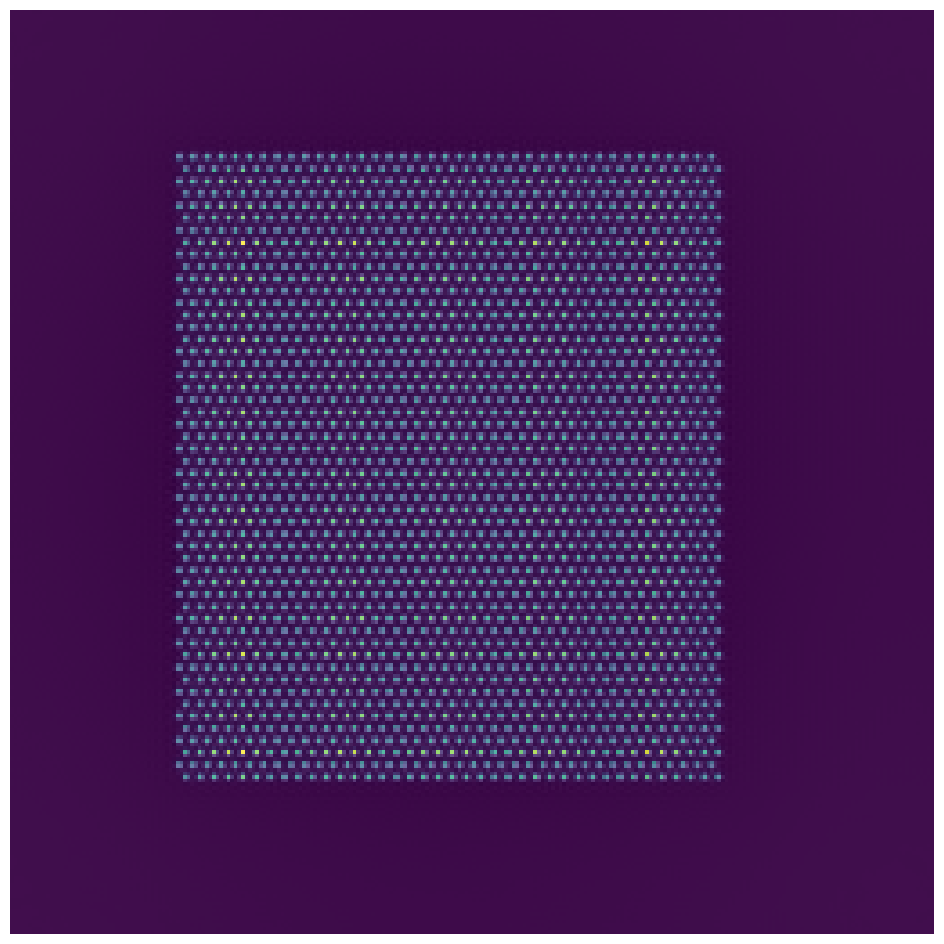

In [117]:
shifted_obj = subpixel_shift(obj, shift=(-2.42, -2.12))

rgba_main = real_array_to_rgba(np.angle(shifted_obj))
fig, ax = plt.subplots(figsize=(12, 12),)
ax.imshow(potential_all, alpha=1)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)
ax.axis('off')

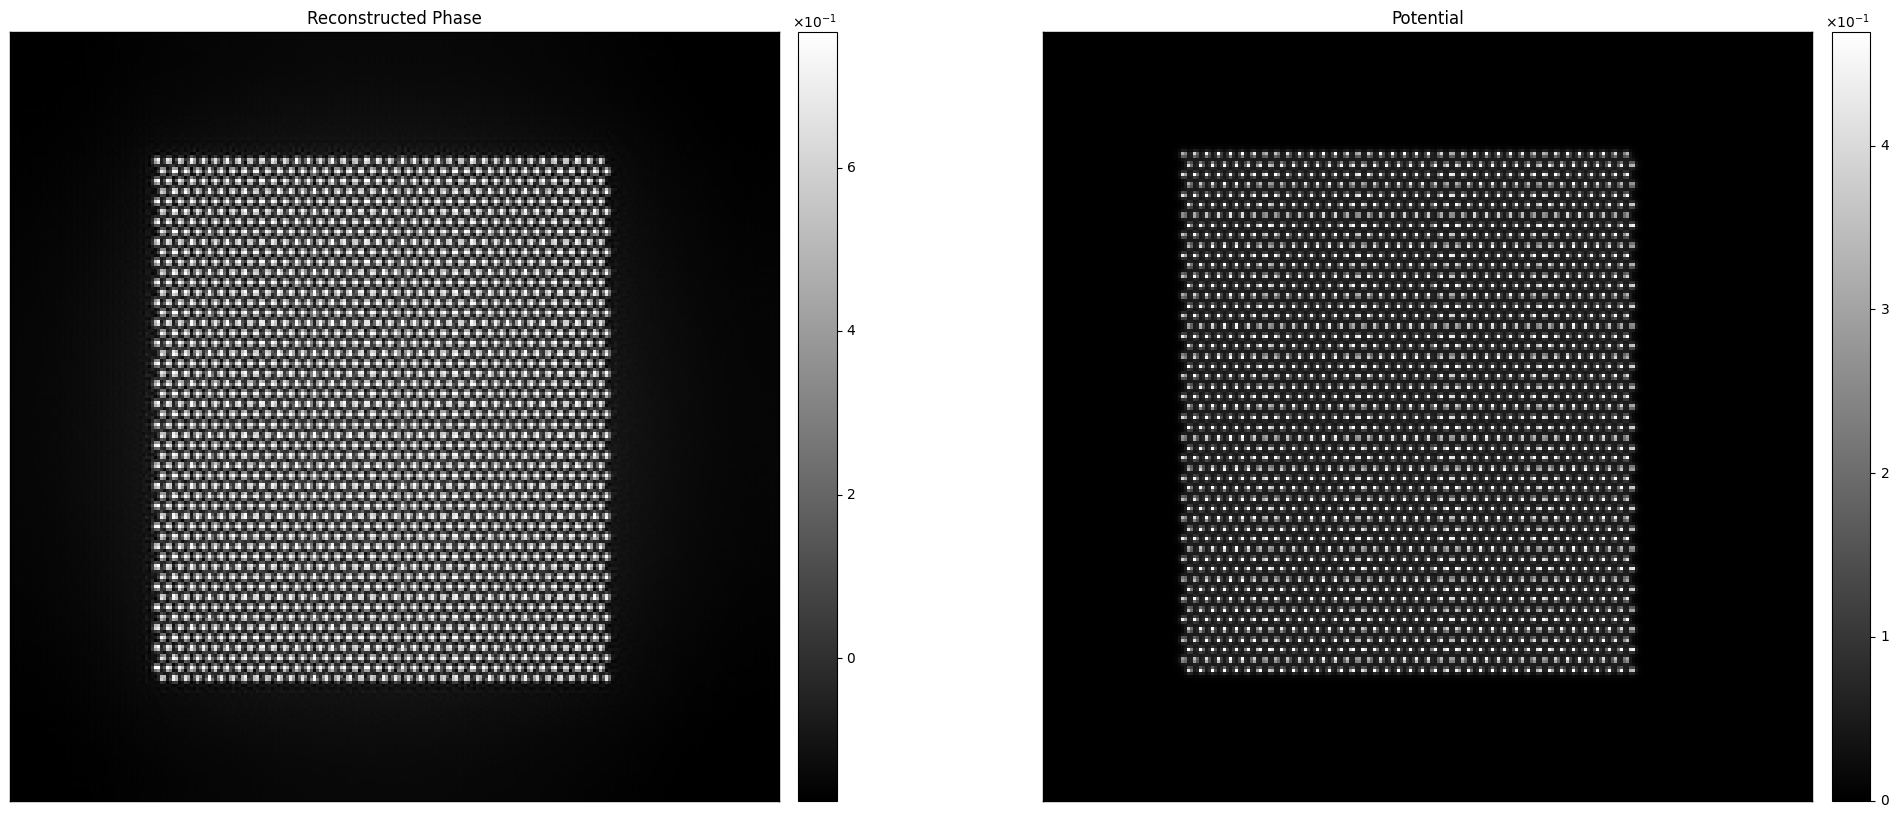

In [118]:
show_2d([np.angle(obj)/np.max(np.angle(obj)), potential_all/np.max(potential_all)],cbar=True,axsize=(12,12), titles=["Reconstructed Phase", "Potential"])
norm_obj_phase = np.angle(obj)/np.max(np.angle(obj))
norm_potential = potential_all/np.max(potential_all)

Best shift (row, col): (0.9500, -4.2000) px
Registration error: 0.657848
Peak NCC (0-1, higher=better): 0.8026


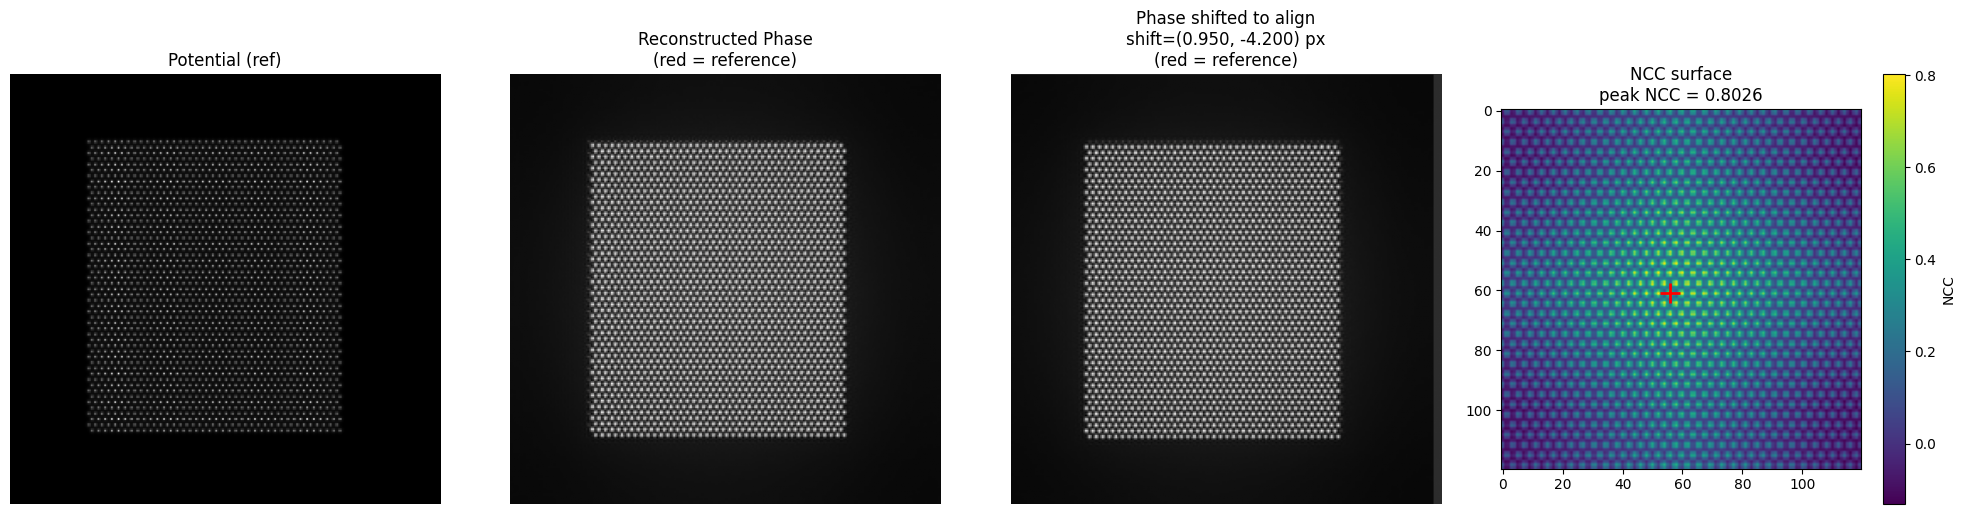

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.registration import phase_cross_correlation
from scipy.signal import fftconvolve

def find_best_shift_xcorr(reference, moving, upsample_factor=20, normalization=None):
    """
    Find the sub-pixel shift that best aligns `moving` to `reference`
    using FFT-based phase cross-correlation, and compute a normalized
    cross-correlation (NCC) surface around the peak to assess goodness of fit.

    Parameters
    ----------
    reference : 2D array (e.g. normalized potential)
    moving : 2D array (e.g. normalized reconstructed phase), same shape as reference
    upsample_factor : int
        Sub-pixel precision = 1/upsample_factor of a pixel
    normalization : None or "phase"
        Passed to phase_cross_correlation; "phase" can help if there's
        amplitude mismatch between the two images

    Returns
    -------
    shift : (row_shift, col_shift) -- shift to apply to `moving` to align to `reference`
    error : registration error metric from phase_cross_correlation
    ncc_peak : peak value of the normalized cross-correlation (0-1, higher = better match)
    ncc_map : the local NCC surface for plotting
    """
    assert reference.shape == moving.shape, "Images must be the same shape"

    # --- Sub-pixel shift via FFT phase correlation ---
    shift, error, diffphase = phase_cross_correlation(
        reference, moving,
        upsample_factor=upsample_factor,
        normalization=normalization,
    )

    # --- Full-resolution NCC map for visualizing correlation goodness ---
    ref_norm = (reference - reference.mean()) / (reference.std() + 1e-12)
    mov_norm = (moving - moving.mean()) / (moving.std() + 1e-12)

    # cross-correlate via FFT convolution with flipped kernel
    ncc_map = fftconvolve(ref_norm, mov_norm[::-1, ::-1], mode="same")
    ncc_map /= ref_norm.size  # normalize by number of pixels -> range ~[-1, 1]

    ncc_peak = ncc_map.max()

    return shift, error, ncc_peak, ncc_map

def plot_xcorr_results(reference, moving, shift, ncc_map, ncc_peak,
                        titles=("Reference", "Moving", "Shifted moving", "NCC surface"),
                        overlay_alpha=0.4):
    from scipy.ndimage import shift as ndi_shift

    shifted_moving = ndi_shift(moving, shift=shift, order=3, mode="constant", cval=0)

    # build a red overlay mask from the reference (normalized 0-1 for alpha scaling)
    ref_norm01 = (reference - reference.min()) / (reference.max() - reference.min() + 1e-12)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(reference, cmap="gray")
    axes[0].set_title(titles[0])

    # --- Moving with reference overlay ---
    axes[1].imshow(moving, cmap="gray")
    axes[1].imshow(np.ones_like(reference), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[1].set_title(f"{titles[1]}\n(red = reference)")

    # --- Shifted moving with reference overlay ---
    axes[2].imshow(shifted_moving, cmap="gray")
    axes[2].imshow(np.ones_like(reference), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[2].set_title(f"{titles[2]}\nshift=({shift[0]:.3f}, {shift[1]:.3f}) px\n(red = reference)")

    # zoom into a window around the correlation peak for readability
    cy, cx = np.array(ncc_map.shape) // 2
    win = min(60, cy, cx)
    ncc_crop = ncc_map[cy-win:cy+win, cx-win:cx+win]

    im = axes[3].imshow(ncc_crop, cmap="viridis")
    peak_local = np.unravel_index(np.argmax(ncc_crop), ncc_crop.shape)
    axes[3].plot(peak_local[1], peak_local[0], "r+", markersize=15, markeredgewidth=2)
    axes[3].set_title(f"{titles[3]}\npeak NCC = {ncc_peak:.4f}")
    fig.colorbar(im, ax=axes[3], label="NCC")

    for ax in axes[:3]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# --- usage with your images ---
shift, error, ncc_peak, ncc_map = find_best_shift_xcorr(
    potential_all, np.angle(obj), upsample_factor=20
)
print(f"Best shift (row, col): ({shift[0]:.4f}, {shift[1]:.4f}) px")
print(f"Registration error: {error:.6f}")
print(f"Peak NCC (0-1, higher=better): {ncc_peak:.4f}")

plot_xcorr_results(potential_all, np.angle(obj), shift, ncc_map, ncc_peak,
                    titles=("Potential (ref)", "Reconstructed Phase", "Phase shifted to align", "NCC surface"))

-0.0542488619685173 3586.627197265625


Gaussian fitting:  71%|███████   | 1438/2028 [00:33<00:24, 24.54it/s]/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:498: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
Gaussian fitting: 100%|██████████| 2028/2028 [01:26<00:00, 23.47it/s]


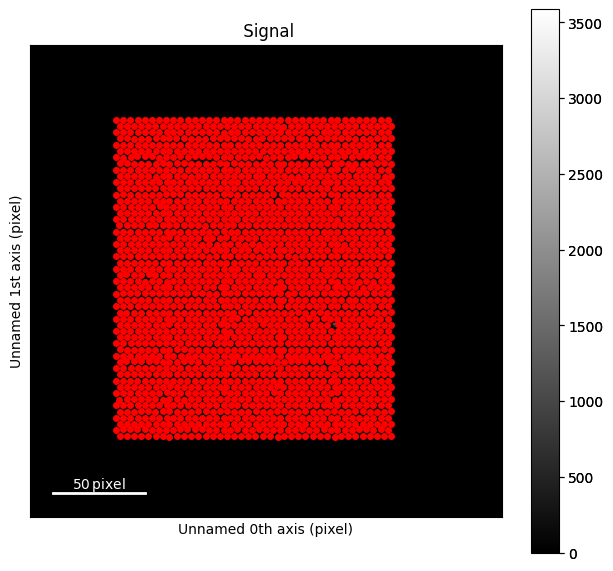

a


In [78]:
import numpy as np
import atomap.api as am
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
import hyperspy.api as hs

gt_image = potential_all.astype(np.float64)
print(gt_image.min(), gt_image.max())
gt_image -= gt_image.min()  # atomap doesn't like negative values

gt_signal = hs.signals.Signal2D(gt_image)

# separation: ~half the nearest-neighbor atom distance, in pixels.
# Tune this based on your lattice spacing in the 256x256 sampling.
separation = 2

atom_positions = am.get_atom_positions(gt_signal, separation=separation, pca=True, threshold_rel=0.1)

sublattice = am.Sublattice(atom_positions, image=gt_image, color='red')
sublattice.find_nearest_neighbors()
sublattice.refine_atom_positions_using_center_of_mass()
sublattice.refine_atom_positions_using_2d_gaussian()

sublattice.plot()  # sanity check the fitted positions over the ground truth
plt.show()
print('a')

refined_positions = np.array(
    [[atom.pixel_x, atom.pixel_y] for atom in sublattice.atom_list]
)

Image data has negative values, with the lowest being -0.49748948216438293. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.49748948216438293, use the fix_negative_values=True parameter


-0.49748948216438293 2.268784523010254


Gaussian fitting: 100%|██████████| 2028/2028 [00:36<00:00, 54.95it/s]


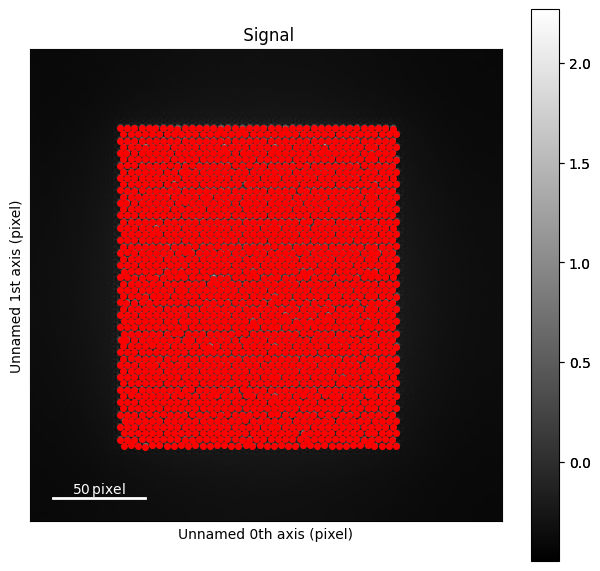

a


In [120]:
gt_image = np.angle(obj).astype(np.float64)
print(gt_image.min(), gt_image.max())
gt_image.clip(0)

gt_signal = hs.signals.Signal2D(gt_image)

# separation: ~half the nearest-neighbor atom distance, in pixels.
# Tune this based on your lattice spacing in the 256x256 sampling.
separation = 1

atom_positions = am.get_atom_positions(gt_signal, separation=separation, pca=True, threshold_rel=0.4)

sublattice = am.Sublattice(atom_positions, image=gt_image, color='red')
sublattice.find_nearest_neighbors()
sublattice.refine_atom_positions_using_center_of_mass()
sublattice.refine_atom_positions_using_2d_gaussian()

sublattice.plot()  # sanity check the fitted positions over the ground truth
plt.show()
print('a')

refined_positions_obj = np.array(
    [[atom.pixel_x, atom.pixel_y] for atom in sublattice.atom_list]
)

Best shift (dx, dy): (-2.1200, -2.4200) px
Registration error: 1.000000
Peak NCC: 0.8134


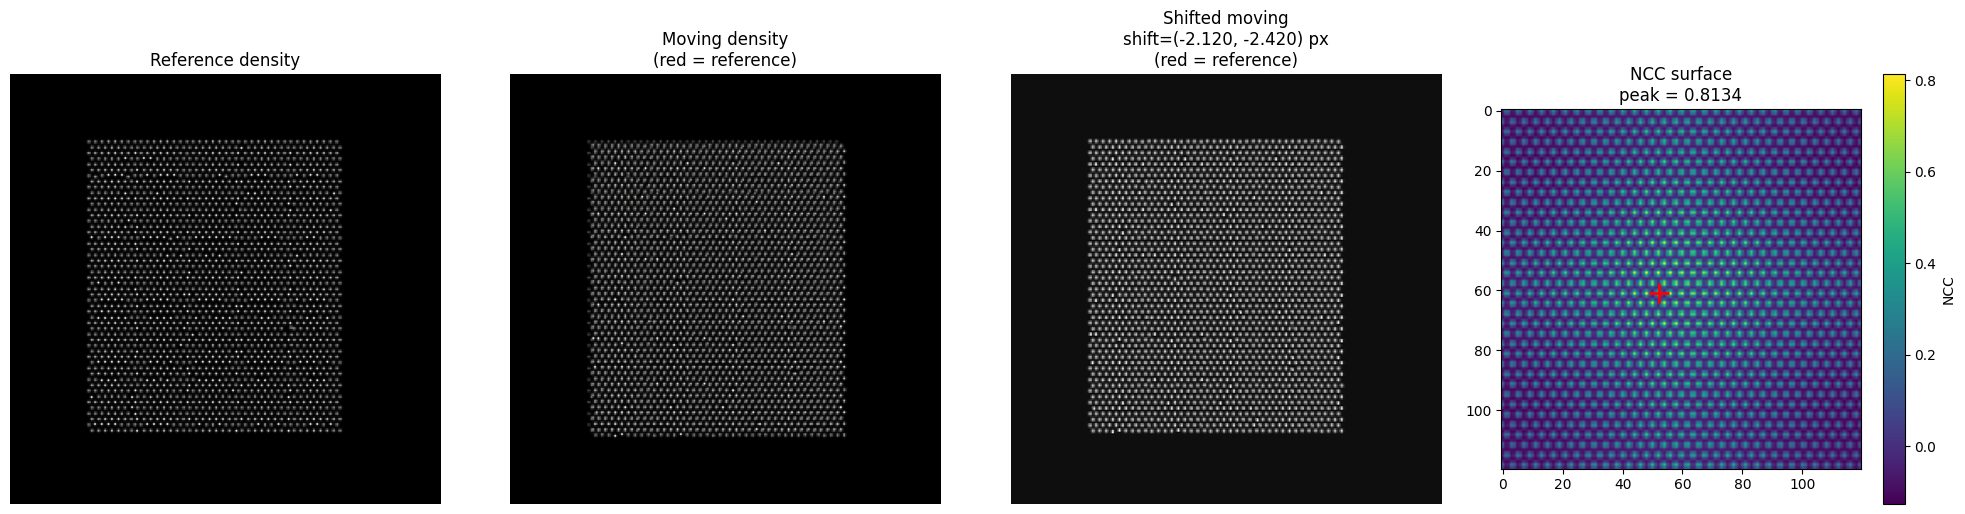

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndi_shift
from scipy.signal import fftconvolve
from skimage.registration import phase_cross_correlation


def rasterize_points(points, image_shape, sigma=2.0):
    """
    Turn a point list (x, y) into a smooth density image via Gaussian-blurred
    delta functions. Sub-pixel point positions are distributed with bilinear
    weights before blurring so we don't lose precision to rounding.
    """
    img = np.zeros(image_shape, dtype=np.float64)
    xs, ys = points[:, 0], points[:, 1]

    x0 = np.floor(xs).astype(int)
    y0 = np.floor(ys).astype(int)
    fx = xs - x0
    fy = ys - y0

    for dx, dy, wx, wy in [(0, 0, 1 - fx, 1 - fy),
                            (1, 0, fx, 1 - fy),
                            (0, 1, 1 - fx, fy),
                            (1, 1, fx, fy)]:
        xi = x0 + dx
        yi = y0 + dy
        valid = (xi >= 0) & (xi < image_shape[1]) & (yi >= 0) & (yi < image_shape[0])
        np.add.at(img, (yi[valid], xi[valid]), (wx * wy)[valid])

    return gaussian_filter(img, sigma=sigma)


def cross_correlate_point_clouds(points_ref, points_mov, image_shape,
                                  sigma=2.0, upsample_factor=50):
    """
    Cross-correlate two point clouds by rasterizing them into density images
    and finding the sub-pixel shift that maximizes their correlation.
    Does NOT require equal point counts or 1:1 correspondence.

    Returns
    -------
    shift : (dx, dy) shift to apply to points_mov to align with points_ref
    error : phase_cross_correlation registration error (lower = better)
    ncc_peak : peak of the normalized cross-correlation (0-1, higher = better match)
    img_ref, img_mov : the rasterized density images (for inspection/plotting)
    """
    img_ref = rasterize_points(points_ref, image_shape, sigma=sigma)
    img_mov = rasterize_points(points_mov, image_shape, sigma=sigma)

    # sub-pixel shift via FFT phase correlation (row, col) = (dy, dx)
    shift_rc, error, _ = phase_cross_correlation(img_ref, img_mov, upsample_factor=upsample_factor)
    shift = np.array([shift_rc[1], shift_rc[0]])  # -> (dx, dy)

    # NCC map for goodness-of-fit visualization
    ref_norm = (img_ref - img_ref.mean()) / (img_ref.std() + 1e-12)
    mov_norm = (img_mov - img_mov.mean()) / (img_mov.std() + 1e-12)
    ncc_map = fftconvolve(ref_norm, mov_norm[::-1, ::-1], mode="same") / ref_norm.size
    ncc_peak = ncc_map.max()

    return shift, error, ncc_peak, img_ref, img_mov, ncc_map


def plot_point_cloud_xcorr(img_ref, img_mov, shift, ncc_map, ncc_peak, overlay_alpha=0.5):
    mov_shifted = ndi_shift(img_mov, shift=(shift[1], shift[0]), order=3, mode="constant", cval=0)

    ref_norm01 = (img_ref - img_ref.min()) / (img_ref.max() - img_ref.min() + 1e-12)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_ref, cmap="gray")
    axes[0].set_title("Reference density")

    axes[1].imshow(img_mov, cmap="gray")
    axes[1].imshow(np.ones_like(img_ref), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[1].set_title("Moving density\n(red = reference)")

    axes[2].imshow(mov_shifted, cmap="gray")
    axes[2].imshow(np.ones_like(img_ref), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[2].set_title(f"Shifted moving\nshift=({shift[0]:.3f}, {shift[1]:.3f}) px\n(red = reference)")

    cy, cx = np.array(ncc_map.shape) // 2
    win = min(60, cy, cx)
    ncc_crop = ncc_map[cy-win:cy+win, cx-win:cx+win]
    im = axes[3].imshow(ncc_crop, cmap="viridis")
    peak_local = np.unravel_index(np.argmax(ncc_crop), ncc_crop.shape)
    axes[3].plot(peak_local[1], peak_local[0], "r+", markersize=15, markeredgewidth=2)
    axes[3].set_title(f"NCC surface\npeak = {ncc_peak:.4f}")
    fig.colorbar(im, ax=axes[3], label="NCC")

    for ax in axes[:3]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# --- usage ---
image_shape = potential_all.shape  # e.g. (256, 256)

shift, error, ncc_peak, img_ref, img_mov, ncc_map = cross_correlate_point_clouds(
    refined_positions, refined_positions_obj, image_shape, sigma=0.5
)
print(f"Best shift (dx, dy): ({shift[0]:.4f}, {shift[1]:.4f}) px")
print(f"Registration error: {error:.6f}")
print(f"Peak NCC: {ncc_peak:.4f}")

plot_point_cloud_xcorr(img_ref, img_mov, shift, ncc_map, ncc_peak)